In [23]:
import numpy as np                                                                        
import matplotlib.pyplot as plt
import pyCloudy as pc
import pyneb as pn
from astropy    import constants as const
from astropy.io import ascii
import pandas as pd
from scipy import interpolate
import warnings
from scipy.integrate import quad, IntegrationWarning
import scipy.integrate as integrate
from numpy import log10, exp
import os
from astropy.constants import c
import astropy.units as u
from scipy import special
import matplotlib.gridspec as gridspec

kpc = const.kpc.cgs.value

def SB(z, radius_kpc, emissivity, dr):
    r_min, r_max = radius_kpc.min(), radius_kpc.max()
    Project_R = np.linspace(0, 100, 70) * kpc
    N = len(Project_R)
    surface_brightness = np.zeros(N)
    Lumin = np.zeros(N)

    from scipy.interpolate import interp1d
    emis_interp = interp1d(radius_kpc, emissivity, bounds_error=False, fill_value=0)
    
    for ii, R in enumerate(Project_R):
        # 적분 함수 정의
        def integrand(r):
            if r < R:
                return 0
            else:
                emis = emis_interp(r)
                return emis * r / np.sqrt(r**2 - R**2)
            
        surface_brightness[ii], _ = quad(integrand, R, r_max)
        surface_brightness[ii] *= 2 / (1+z)**4
    dR =  Project_R[1] - Project_R[0]    
    def lumin_integrand(R):
        if R == 0 :
            area = np.pi * (0.5*dR)**2
        elif R == r_max:
            area = np.pi * (2*R +0.5*dR)*0.5*dR 
        else:
            area = 2 * np.pi * R * np.interp(R, Project_R, surface_brightness)
        
        return area
    
    Lumin, _ = quad(lumin_integrand, 0, r_max)
    
    return Project_R / kpc, surface_brightness, Lumin


def process_continue_string(s):
    # continue(...) 안의 내용만 추출
    values = s.str.extract(r'continue\((.*?)\)')[0]
    # 쉼표나 탭이나 공백으로 분리
    split_values = values.str.split(r'[,\t\s]+', expand=True)
    # 첫 두 컬럼만 사용하여 데이터프레임 생성
    df = pd.DataFrame({
        'x': split_values[0].astype(float),
        'y': split_values[1].astype(float) 
    })
    return df


In [24]:
import numpy as np                                                                        
import matplotlib.pyplot as plt
import pyCloudy as pc
import pyneb as pn
from astropy    import constants as const
from astropy.io import ascii
import pandas as pd
from scipy import interpolate
import warnings
from scipy.integrate import quad, IntegrationWarning
import scipy.integrate as integrate
from numpy import log10, exp
import os
from astropy.constants import c
import astropy.units as u
from scipy import special
from scipy.interpolate import interp1d

warnings.filterwarnings("ignore", category=IntegrationWarning)

# kpc = const.kpc.cgs.value

# atom = ['Lya','HeII','CIV']



def radius(path, atom):
    Mod = pc.CloudyModel(path, cloudy_version_major=17)
    radius = Mod.radius/kpc
    radius_kpc =Mod.radius 
    dr = Mod.dr 
    return radius, radius_kpc, dr


def SB(z, radius_kpc, emissivity, dr):
    r_min, r_max = radius_kpc.min(), radius_kpc.max()
    Project_R = np.linspace(0, 100, 80) * kpc
    N = len(Project_R)
    surface_brightness = np.zeros(N)
    Lumin = np.zeros(N)

    
    emis_interp = interp1d(radius_kpc, emissivity, bounds_error=False, fill_value=0)
    
    for ii, R in enumerate(Project_R):
        # 적분 함수 정의
        def integrand(r):
            if r < R:
                return 0
            else:
                emis = emis_interp(r)
                return emis * r / np.sqrt(r**2 - R**2)
            
        surface_brightness[ii], _ = quad(integrand, R, r_max)
        surface_brightness[ii] *= 2 / (1+z)**4
    dR =  Project_R[1] - Project_R[0]    
    def lumin_integrand(R):
        if R == 0 :
            area = np.pi * (0.5*dR)**2
        elif R == r_max:
            area = np.pi * (2*R +0.5*dR)*0.5*dR 
        else:
            area = 2 * np.pi * R * np.interp(R, Project_R, surface_brightness)
        
        return area
    
    Lumin, _ = quad(lumin_integrand, 0, r_max)
    
    return Project_R / kpc, surface_brightness, Lumin



def RT_SB(path):
    name = ['radius','SB_K','SB_H','SB_tot','1','2','3']
    data_sp = pd.read_csv(path, sep='\s+', header=None,names=name)
    rad, SB_t, SB_k,SB_h =  data_sp['radius'].to_numpy(),data_sp['SB_tot'].to_numpy(),data_sp['SB_K'].to_numpy(),data_sp['SB_H'].to_numpy()
    return rad*100, rad*100*kpc, SB_t 





def read_file(path_way, atom):
    Mod = pc.CloudyModel(path_way, cloudy_version_major=23)
    Mod.ionic_names

    N_H = sum(Mod.dr*Mod.nH)
    # solar_metallicity
    frac_He =1.00E-01
    frac_C = 2.45E-04
    frac_O = 4.90E-04
    frac_N = 8.51E-05
    frac_Mg = 3.47E-05

    N_HI = sum(Mod.dr*Mod.nH*Mod.get_ionic('H',0))
    N_HII = sum(Mod.dr*Mod.nH*Mod.get_ionic('H',1))
    N_HeII = frac_He*sum(Mod.dr*Mod.nH*Mod.get_ionic('He',1))
    N_OVI = frac_O*sum(Mod.dr*Mod.nH*Mod.get_ionic('O',5))
    N_NV = frac_N*sum(Mod.dr*Mod.nH*Mod.get_ionic('N',4))
    N_CIV = frac_C*sum(Mod.dr*Mod.nH*Mod.get_ionic('C',3))

    num = len(Mod.nH)
    r_CIV = path_way +  '.ele_C'
    f = open(r_CIV,'r')
    header = f.readline()
    CIV_frac = np.zeros(num)
    i = 0
    for line in f:
        line = line.strip()
        columns = line.split()
        j = float(columns[4])
        CIV_frac[i] = j
        i = i + 1

    r_He = path_way +  '.ele_He'
    f = open(r_He,'r')
    header = f.readline()
    HeII_frac = np.zeros(num)
    i = 0
    for line in f:
        line = line.strip()
        columns = line.split()
        j = float(columns[2])
        HeII_frac[i] = j
        i = i + 1



    n_H= Mod.nH
    n_He = n_H*frac_He
    n_C = n_H*frac_C
    nden_CIV = CIV_frac*n_C
    nden_HeII = HeII_frac*n_He



    if atom == 'CIV':
        Cloudy_Lum = float(Mod.get_emis_vol('C__4_154819A')) + float(Mod.get_emis_vol('C__4_155078A'))
        Cloudy_emis = (Mod.get_emis('C__4_154819A')) + (Mod.get_emis('C__4_155078A'))
        Cloudy_den = nden_CIV
        Cloudy_Nden = N_CIV

    elif atom == 'Lya':
        Cloudy_Lum= float(Mod.get_emis_vol('H__1_121567A'))
        Cloudy_emis = Mod.get_emis('H__1_121567A')
        Cloudy_den = n_H
        Cloudy_Nden = N_H


    elif atom == 'HeII':
        Cloudy_Lum = float(Mod.get_emis_vol('HE_2_164043A'))
        Cloudy_emis = Mod.get_emis('HE_2_164043A')
        Cloudy_den = nden_HeII
        Cloudy_Nden = N_HeII

    return Cloudy_Lum , Cloudy_emis ,Cloudy_den, Cloudy_Nden

def path(Lum,N_H,version,multi):

    path_way = f'/home/jin/RT/RT_cloudy_Masking/Lum_{Lum}_{version}/N_H_{multi}_{N_H}/w_LT'
    
    if version == 1 or version == 2 or version == 5 or version == 6:
        path_CIV = os.path.join(path_way, f'QSO/CIV_QSO')
        path_qso = os.path.join(path_way, f'QSO/QSO.sed')
    else :
        path_CIV = os.path.join(path_way, f'QSO_M/CIV_QSO')
        path_qso = os.path.join(path_way, f'QSO_M/QSO_masking.sed')

    return path_CIV , path_qso

In [25]:
def CLOUDY_data(Lum,N_H,version,multi):
    path_way , path_qso = path(Lum,N_H,version,multi)

    Mod = pc.CloudyModel(path_way)
    Mod.ionic_names
    N_H = sum(Mod.dr*Mod.nH)

    # solar_metallicity
    frac_He =1.00E-01
    frac_C = 2.45E-04
    frac_O = 4.90E-04
    frac_N = 8.51E-05
    frac_Mg = 3.47E-05

    N_HI = sum(Mod.dr*Mod.nH*Mod.get_ionic('H',0))
    N_HII = sum(Mod.dr*Mod.nH*Mod.get_ionic('H',1))
    N_HeII = frac_He*sum(Mod.dr*Mod.nH*Mod.get_ionic('He',1))
    N_OVI = frac_O*sum(Mod.dr*Mod.nH*Mod.get_ionic('O',5))
    N_NV = frac_N*sum(Mod.dr*Mod.nH*Mod.get_ionic('N',4))
    N_CIV = frac_C*sum(Mod.dr*Mod.nH*Mod.get_ionic('C',3))

    num = len(Mod.nH)
    r_CIV = path_way +  '.ele_C'
    f = open(r_CIV,'r')
    header = f.readline()
    CIV_frac = np.zeros(num)
    i = 0
    for line in f:
        line = line.strip()
        columns = line.split()
        j = float(columns[4])
        CIV_frac[i] = j
        i = i + 1

    r_CIV = path_way +  '.ele_C'
    f = open(r_CIV,'r')
    header = f.readline()
    CV_frac = np.zeros(num)
    i = 0
    for line in f:
        line = line.strip()
        columns = line.split()
        j = float(columns[5])
        CV_frac[i] = j
        i = i + 1

    r_CIV = path_way +  '.ele_C'
    f = open(r_CIV,'r')
    header = f.readline()
    CIII_frac = np.zeros(num)
    i = 0
    for line in f:
        line = line.strip()
        columns = line.split()
        j = float(columns[3])
        CIII_frac[i] = j
        i = i + 1

    r_He = path_way +  '.ele_He'
    f = open(r_He,'r')
    header = f.readline()
    HeII_frac = np.zeros(num)
    i = 0
    for line in f:
        line = line.strip()
        columns = line.split()
        j = float(columns[2])
        HeII_frac[i] = j
        i = i + 1

    r_He = path_way +  '.ele_He'
    f = open(r_He,'r')
    header = f.readline()
    HeIII_frac = np.zeros(num)
    i = 0
    for line in f:
        line = line.strip()
        columns = line.split()
        j = float(columns[3])
        HeIII_frac[i] = j
        i = i + 1
        
    r_He = path_way +  '.ele_He'
    f = open(r_He,'r')
    header = f.readline()
    HeI_frac = np.zeros(num)
    i = 0
    for line in f:
        line = line.strip()
        columns = line.split()
        j = float(columns[1])
        HeI_frac[i] = j
        i = i + 1



    r_H = path_way +  '.ele_H'
    f = open(r_H,'r')
    header = f.readline()
    HII_frac = np.zeros(num)
    i = 0
    for line in f:
        line = line.strip()
        columns = line.split()
        j = float(columns[2])
        HII_frac[i] = j
        i = i + 1

    r_H = path_way +  '.ele_H'
    f = open(r_H,'r')
    header = f.readline()
    HI_frac = np.zeros(num)
    i = 0
    for line in f:
        line = line.strip()
        columns = line.split()
        j = float(columns[1])
        HI_frac[i] = j
        i = i + 1



    radius = Mod.radius/kpc
    radius_kpc =Mod.radius 
    dr = Mod.dr 


    n_H= Mod.nH
    n_e = Mod.ne
    n_He = n_H*frac_He
    n_C = n_H*frac_C
    nden_CIV = CIV_frac*n_C
    nden_HeII = HeII_frac*n_He


    CIV_Lum = float(Mod.get_emis_vol('C__4_154819A')) + float(Mod.get_emis_vol('C__4_155078A'))
    CIV_emis = (Mod.get_emis('C__4_154819A')) + (Mod.get_emis('C__4_155078A'))
    CIV_den = nden_CIV

    Lya_Lum= float(Mod.get_emis_vol('H__1_121567A'))
    Lya_emis = Mod.get_emis('H__1_121567A')
    Lya_den = n_H

    HeII_Lum = float(Mod.get_emis_vol('HE_2_164043A'))
    HeII_emis = Mod.get_emis('HE_2_164043A')
    HeII_den = nden_HeII


    # Mod.print_stats()

    CIV_Column_density = np.sum(dr*CIV_den)
    HeII_Column_density = np.sum(dr*HeII_den)
    Lya_Column_density = np.sum(dr*Lya_den)

    H_Column_density = np.sum(dr*n_H)
    
    globals()[f'radius_p_{Lum}_{version}'],globals()[f'SB_CIV_{Lum}_{version}'],globals()[f'Lumin_CIV_{Lum}_{version}'] = SB(0,radius_kpc,CIV_emis,dr)
    globals()[f'radius_p_{Lum}_{version}'],globals()[f'SB_HeII_{Lum}_{version}'],globals()[f'Lumin_HeII_{Lum}_{version}'] = SB(0,radius_kpc,HeII_emis,dr)
    globals()[f'radius_p_{Lum}_{version}'],globals()[f'SB_Lya_{Lum}_{version}'],globals()[f'Lumin_Lya_{Lum}_{version}'] = SB(0,radius_kpc,Lya_emis,dr)
    globals()[f'radius_{Lum}_{version}'] , globals()[f'radius_kpc_{Lum}_{version}'] = radius , radius_kpc


    globals()[f'frac_CIII_{Lum}_{version}'], globals()[f'frac_CV_{Lum}_{version}'] = CIII_frac, CV_frac
    globals()[f'frac_HeI_{Lum}_{version}'], globals()[f'frac_HeIII_{Lum}_{version}'] = HeI_frac, HeIII_frac
    globals()[f'frac_HI_{Lum}_{version}'], globals()[f'frac_HII_{Lum}_{version}'] = HI_frac, HII_frac
    globals()[f'ne_{Lum}_{version}'] , globals()[f'Te_{Lum}_{version}'] , globals()[f'Teff_{Lum}_{version}'] = n_e, Mod.te, Mod.Teff
    globals()[f'logU_{Lum}_{version}'] = Mod.log_U
    globals()[f'nH_{Lum}_{version}'] = n_H


    globals()[f'frac_CIV_{Lum}_{version}'],globals()[f'emis_CIV_{Lum}_{version}'],globals()[f'nden_CIV_{Lum}_{version}'] = CIV_frac, CIV_emis, CIV_den 
    globals()[f'frac_HeII_{Lum}_{version}'],globals()[f'emis_HeII_{Lum}_{version}'],globals()[f'nden_HeII_{Lum}_{version}'] = HeII_frac, HeII_emis, HeII_den


    name = ['a','b','c']
    data = pd.read_csv(path_qso,sep='\t',comment='#',names=name)
    data = data[:-1]
    xx = data['a'].to_numpy().astype(float)
    yy = data['b'].to_numpy()
    globals()[f'ryd_x_{version}'],globals()[f'ryd_y_{version}'] = xx, yy      
    


import warnings
from astropy import units as u
from astropy.constants import h, c, k_B
warnings.filterwarnings('ignore')
h_ev = h.to(u.eV *u.s).value
const_nu = (13.6/h_ev)

In [26]:

rr = np.arange(13, 17, 1)
atom = [13,20,32,50,79]
rr_reshaped = rr.reshape(-1, 1)
total_N_c = 10**rr_reshaped * atom / 10
total_N_c = total_N_c.flatten()

C_IV_K = 1548.187e-8  # cm
C_IV_H = 1550.772e-8  # cm

C_IV_K_A = 1548.187  # cm
C_IV_H_A = 1550.772  # cm

cc = c.to(u.cm / u.s).value  # cm/s
cc_k = c.to(u.km / u.s).value #km / s
v_th_CIV = 11.7673179819719e5  # cm/s

K_gamma = 2.65e+8
H_gamma = 2.64e+8
f_CIV_K = 0.190
f_CIV_H = 0.0952

lam_c =  (C_IV_K_A + C_IV_H_A) / 2

voigt_path_11_8 = r'/home/jin/RT/RT_main/CIV_Voigt_data/CIV_Voigt_11_8.txt'
voigt_path_30 = r'/home/jin/RT/RT_main/CIV_Voigt_data/CIV_Voigt_30.txt'
voigt_path_50 = r'/home/jin/RT/RT_main/CIV_Voigt_data/CIV_Voigt_50.txt'

NN = int(1e4)


C_IV_N = np.linspace(1e12, 1e17, NN)

def N_esc_scat(line,voigt_path,v_th):


    name = ['lambda','sigma']
    voigt_file = pd.read_csv(voigt_path,sep='\s+',names=name,)
    lam_0, scat_0 = voigt_file['lambda'].to_numpy() , voigt_file['sigma'].to_numpy()

    del_V =  ((lam_0-C_IV_K) / C_IV_K) * cc /1e5
    x =   del_V / (v_th/1e5)
    K_H_center = 250  / (v_th/1e5)
    dx = x[1] - x[0]
    x_K = x[np.where(x <= K_H_center)[0]]
    x_H = x[np.where(x >= K_H_center)[0]]
    scat_K = scat_0[np.where(x <= K_H_center)[0]]
    scat_H = scat_0[np.where(x >= K_H_center)[0]]
    x_0 = np.zeros(NN)

    xx_K = 0
    xx_H = 500/ (v_th/1e5)

    if line =='K' or line =='k' :
        x = x_K
        scat = scat_K
        xx_c = xx_K
        ii = np.where( (x > -dx/2) & (x < dx/2) )[0]
        cross_sec_cen, N_CIV_cen =  (scat[ii]) ,1/scat[ii]

    elif line == 'H' or line =='h' :
        x = x_H 
        scat = scat_H
        xx_c = xx_H
        jj = np.where( (x > xx_H -dx/2) & (x < xx_H +dx/2) )[0]
        cross_sec_cen, N_CIV_cen =  (scat[jj]) ,1/scat[jj]



    tau_profile = np.outer(C_IV_N, scat)
    
    # print(line,'scattering cross-section = ', cross_sec_cen )
    print(line,'Center  Columne density = ', N_CIV_cen  )


    for ii, jj in enumerate(C_IV_N):
        x_p = np.where(np.diff(np.sign(1 - tau_profile[ii, :])))[0]
        x_0[ii] = x[x_p].max() if x_p.size > 0 else 0


    V_del_peak = 2*abs( (x_0 - xx_c)*(v_th/1e5))

    del_lam_D = v_th / C_IV_K
    nu_0_K= cc/C_IV_K
    nu_esc = x_0*del_lam_D + nu_0_K
    # V_del_peak = 2 * abs((nu_esc - nu_0_K)/nu_0_K) * cc/1e5 #km/s
    v_esc = x_0*v_th
    N_esc= 1/special.erfc(v_esc/v_th)

    
    return x ,tau_profile , V_del_peak , N_esc


def calculate_order_and_value(value):

    if value == 0 :
        return "000" , 0
    elif value == 1:
        return int(value * 100), 0
    elif value < 100:
        return int(value * 10), 1
    elif value < 1000:
        return int(value), 2
    else :
        return int(value / 10), 3


#combine K and H lines
def data_sp_com_RT(Line , Lum, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)

    path = r'/home/jin/RT/RT_scat/N_H_1_22/CIV_data_Lum_{}/N_atom000E+00_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}spec_com.dat'.format(Lum, out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)


    lam = data[0].to_numpy()
    spec_tot = data[1].to_numpy() # total photon
    spec_sc = data[2].to_numpy()  # scattering photon
   # spec_pol_tot = data[3]  # polization of the total photon
   # spec_pol_scat = data[4]  $ polization of the scattering photon
    return lam , spec_tot , spec_sc



#separate K and H line
def data_sp_RT(Line , Lum, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)
    
    if Lum == 45.5:
        Lum = 455

    # path = r'/home/jin/data_CIV/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}spec.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    path = r'/home/jin/RT/RT_scat/N_H_1_22/CIV_data_Lum_{}/N_atom000E+00_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}spec.dat'.format(Lum, out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)


    x = data[0].to_numpy()
    if Line == 'h' or Line =='H':
        lam = -  C_IV_H_A / ( (vran/cc_k)*x -1)
        spec_tot = data[2].to_numpy()
        spec_scat = data[4].to_numpy()

    elif Line == 'k' or Line =='K':
        lam = - C_IV_K_A / ( (vran/cc_k)*x -1)
        spec_tot = data[1].to_numpy()
        spec_scat = data[3].to_numpy()       

    
    return lam , spec_tot , spec_scat


def data_scat_RT(Line ,Lum, vout, vemit, vran):
    out, out_order = calculate_order_and_value(vout)
    emit, emit_order = calculate_order_and_value(vemit)
    ran , ran_order = calculate_order_and_value(vran)
    if Lum == 45.5:
        Lum = 455
    # path = r'/home/jin/data_CIV/N_atom{}0E+{}_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}_f_esc.dat'.format(atom_num, atom_index , out, out_order, emit, emit_order, ran, ran_order)
    path = r'/home/jin/RT/RT_scat/N_H_1_22/CIV_data_Lum_{}/N_atom000E+00_Vexp{}E+0{}_Vemit{}E+0{}_tauD000E+00_Vran{}E+0{}_f_esc.dat'.format(Lum, out, out_order, emit, emit_order, ran, ran_order)
    try:
        data = pd.read_csv(path, sep='\s+', header=None)
    except:
        print('파일을 찾을 수 없습니다.',path)

    if Line == 'k' or Line =='K':
        N_sct = data.iloc[0,4]

    elif Line == 'h' or Line =='H':
        N_sct = data.iloc[0,5]

    return N_sct
    


def K_H_from_Combine_data_RT(Line , Lum, vout, vemit, vran):
    if Lum == 45.5:
        Lum = 455 
    lam , spec_tot , spec_halo =  data_sp_com_RT(Line , Lum, vout, vemit, vran)
    if Line == 'k' or Line =='K':
        ioc = np.where(lam<=lam_c)[0]
        lam_x = lam[ioc]
        spec_tot_x = spec_tot[ioc]
        spec_halo_x  = spec_halo[ioc]

    elif Line == 'h' or Line =='H':
        ioc = np.where(lam>=lam_c)[0]
        lam_x = lam[ioc]
        spec_tot_x = spec_tot[ioc]
        spec_halo_x  = spec_halo[ioc]
    else :
        lam_x  = lam 
        spec_tot_x = spec_tot
        spec_halo_x = spec_halo

    return lam_x , spec_tot_x , spec_halo_x

lam, spec_tot , spec_halo = K_H_from_Combine_data_RT('all','44',200,100,100)
# plt.plot(lam,spec_tot)
# plt.axvline(x=1549,ymin=0,ymax=2)

from scipy.signal import find_peaks

# 빛의 속도 (km/s)

def del_v_peaks_RT(Line, Lum, vout, vemit, vran):
    if Lum == 45.5:
        Lum = 455
    lam, spec_tot, spec_halo = data_sp_com_RT(Line, Lum, vout, vemit, vran)

    # 모든 피크 찾기
    peaks, properties = find_peaks(spec_halo)

    if len(peaks) < 2:
        # 피크가 2개 미만이면 del_v = 0
        del_v = 0
        peak_lambda = []
        peak_values = []
    else:
        # 모든 피크 중 강도 높은 상위 2개 선택
        peak_intensities = spec_halo[peaks]
        top_2_indices = np.argsort(peak_intensities)[-2:]  # 가장 강한 2개의 피크 선택
        top_2_indices = peaks[top_2_indices]  # 원래 인덱스로 변환

        # 피크 파장 및 강도
        peak_lambda = lam[top_2_indices]
        peak_values = spec_halo[top_2_indices]

        # 기준 파장 설정 (C_IV_K_A, C_IV_H_A는 미리 정의되어 있어야 함)
        if Line in ['k', 'K']:
            lambda_0 = C_IV_K_A
        elif Line in ['h', 'H']:
            lambda_0 = C_IV_H_A
        else:
            raise ValueError("Invalid Line input. Must be 'k' or 'h'.")

        # **추가: 피크 강도 차이가 10,000 이상이면 double peak이 아님**
        if abs(peak_values[0] - peak_values[1]) > 20000  or abs(peak_lambda[0] - peak_lambda[1]) < 0.05 :
            del_v = 0
        else:
            # 속도 변환 (v = c * (lambda - lambda_0) / lambda_0)
            peak_velocities = cc_k * (peak_lambda - lambda_0) / lambda_0
            del_v = abs(peak_velocities[1] - peak_velocities[0])  # 속도 차이 계산

    return del_v, peak_lambda



def doublet_ratio_RT(Line,Lum, vout, vemit, vran):
    if Lum == 45.5:
        Lum = 455
    lam_K , spec_tot_K , spec_halo_K = K_H_from_Combine_data_RT('k', Lum, vout, vemit, vran)
    lam_H , spec_tot_H , spec_halo_H = K_H_from_Combine_data_RT('h',Lum , vout, vemit, vran)

    lam_c =  (C_IV_K_A + C_IV_H_A) / 2 

    cut_off_K = np.where(lam_K >= C_IV_K_A + (C_IV_K_A-lam_c))[0]
    cut_off_H = np.where(lam_H <= C_IV_H_A + abs(C_IV_H_A-lam_c))[0]


    cut_spec_tot_K = spec_tot_K[cut_off_K]
    cut_spec_tot_H = spec_tot_H[cut_off_H]

    doublet_line_ratio = np.sum(cut_spec_tot_K) / np.sum(cut_spec_tot_H)

    return doublet_line_ratio


def lam_to_vel(lam):
    vel = (lam - C_IV_K_A) * cc_k / C_IV_K_A   # km/s
    return vel




def tau_0(Line, atom_num, atom_index, vout, vemit, vran):
    if Line == 'h' or Line =='H':
        f_c = f_CIV_H

    elif Line == 'k' or Line =='K':
        f_c = f_CIV_K
    T = 1e5
    M = 12
    N_t = (atom_num/10) * 10**(atom_index)
    tau = 1.9 * (f_c / 0.4164) * (T/1e5)**(-0.5) * (M)**(0.5) * (N_t /10**14)
    return tau

In [27]:
def calculate_order_and_value(value):
    """ 주어진 값에 대해 변환된 값과 해당 order 반환 """

    if value == 0 :
        return "000" , 0
    elif value == 1:
        return int(value * 100), 0
    elif value < 100:
        return int(value * 10), 1
    elif value < 1000:
        return int(value), 2

    return int(value / 10), 3


def RT_make_parameter(z_red_Shift,lum,v_out, v_emit, v_rand, atom):
    # 기본값 설정
    radius_RT, radius_kpc_RT, SB_RT = np.array([0]), np.array([0]), np.array([0])
    radius_CL, sb_CL = np.array([0]), np.array([0])
    normal_RT, normal_CL = 1, 1  # ZeroDivisionError 방지

    if v_out == 0:
        expand, vout_order = "000", 0
    elif v_out >= 1000:
        expand, vout_order = int(v_out/10), 3
    else:
        expand, vout_order = v_out, 2
    # print(v_emit)
    emit, emit_order = calculate_order_and_value(v_emit)    
    # print(emit,emit_order)
    rand, rand_order = calculate_order_and_value(v_rand)
    # print(rand)
    ll = 0
    # 파일 경로 설정
    if lum == 43.5 or lum== 45.5:
        lum = int(lum * 10)
    else : lum = lum 
    #ubuntu
    # if v_out == 0 :
    #     # N_H_1_22/{atom}_test_Photon_10_5
    #     path_rt = (f'/home/jin/RT/RT_scat/N_H_1_22/{atom}_test_Photon_10_5/{atom}_data_Lum_{lum}/N_atom000E+00_'
    #             f'Vexp{expand}E+0{vout_order}_Vemit{emit}E+0{emit_order}_'
    #             f'tauD000E+00_Vran{rand}E+0{rand_order}radi.dat')
    # else :
    path_rt = (f'/home/jin/RT/RT_scat/N_H_1_22/{atom}_data_Lum_{lum}/N_atom000E+00_'
                f'Vexp{expand}E+0{vout_order}_Vemit{emit}E+0{emit_order}_'
                f'tauD000E+00_Vran{rand}E+0{rand_order}radi.dat')        
    #window
    # path_rt = (f'/home/jin/RT/RT_main/sb_cloudy/data_RT/N_atom000E+00_'
    #             f'Vexp{expand}E+0{vout_order}_Vemit{emit}E+0{emit_order}_'
    #             f'tauD000E+00_Vran{rand}E+0{rand_order}radi.dat')


    # RT_SB 함수 호출
    rt_output = RT_SB(path_rt)
    if rt_output is not None:
        radius_RT, radius_kpc_RT, SB_RT = rt_output

    # SB_RT 값이 None이거나 비어있을 경우 기본값 설정
    if SB_RT is None or len(SB_RT) == 0:
        SB_RT = np.array([0])
    normal_RT = np.sum(SB_RT) if np.sum(SB_RT) != 0 else 1

    print(f"make parameters of v_rand = {v_rand} km/s, v_exp = {v_out} km/s, v_emit = {v_emit} km/s for {atom}")


    return radius_RT, radius_kpc_RT,  SB_RT/ normal_RT, SB_RT   


def vout_make_parameter(z_red_Shift,lum,v_out, v_emit ,v_rand):
    for ii in v_out:
        nn = int(ii / 100)
        globals()['RT_radius_vout_{}'.format(nn)] , globals()['RT_radius_kpc_vout_{}'.format(nn)], globals()['Norm_RT_SB_vout_{}'.format(nn)] , globals()['Origin_SB_vout_{}'.format(nn)]= RT_make_parameter(z_red_Shift,lum,ii, v_emit, v_rand,'CIV')[:4]
    return print("Make data!!")

def photon_number_SB(radius,origin_SB,CIV_lum):
    R_rt =  radius/ 100 
    dR = R_rt[1] - R_rt[0]
    number_dis= np.zeros(len(R_rt))
    surface_brightness_RT = np.zeros(len(R_rt))
    for ii, R in enumerate(R_rt):
        if R == 0 :
            area = np.pi * (0.5*dR)**2
        elif R ==R_rt[-1]:
            area = np.pi * (2*R +0.5*dR)*0.5*dR 
        else :
            area = 2*np.pi*R*dR
        number_dis[ii] = origin_SB[ii] * area 
        
    total_Number = np.sum(number_dis).astype(int)
    factor_atom = CIV_lum / total_Number 
    
    for ii, R in enumerate(R_rt):
        if R == 0 :
            area = np.pi * (0.5*dR)**2
        elif R ==R_rt[-1]:
            area = np.pi * (2*R +0.5*dR)*0.5*dR 
        else :
            area = 2*np.pi*R*dR
        factor_area = (100*kpc)**2
        surface_brightness_RT[ii] = number_dis[ii] * factor_atom / (area*factor_area) 




    return number_dis , surface_brightness_RT




Lum = 44


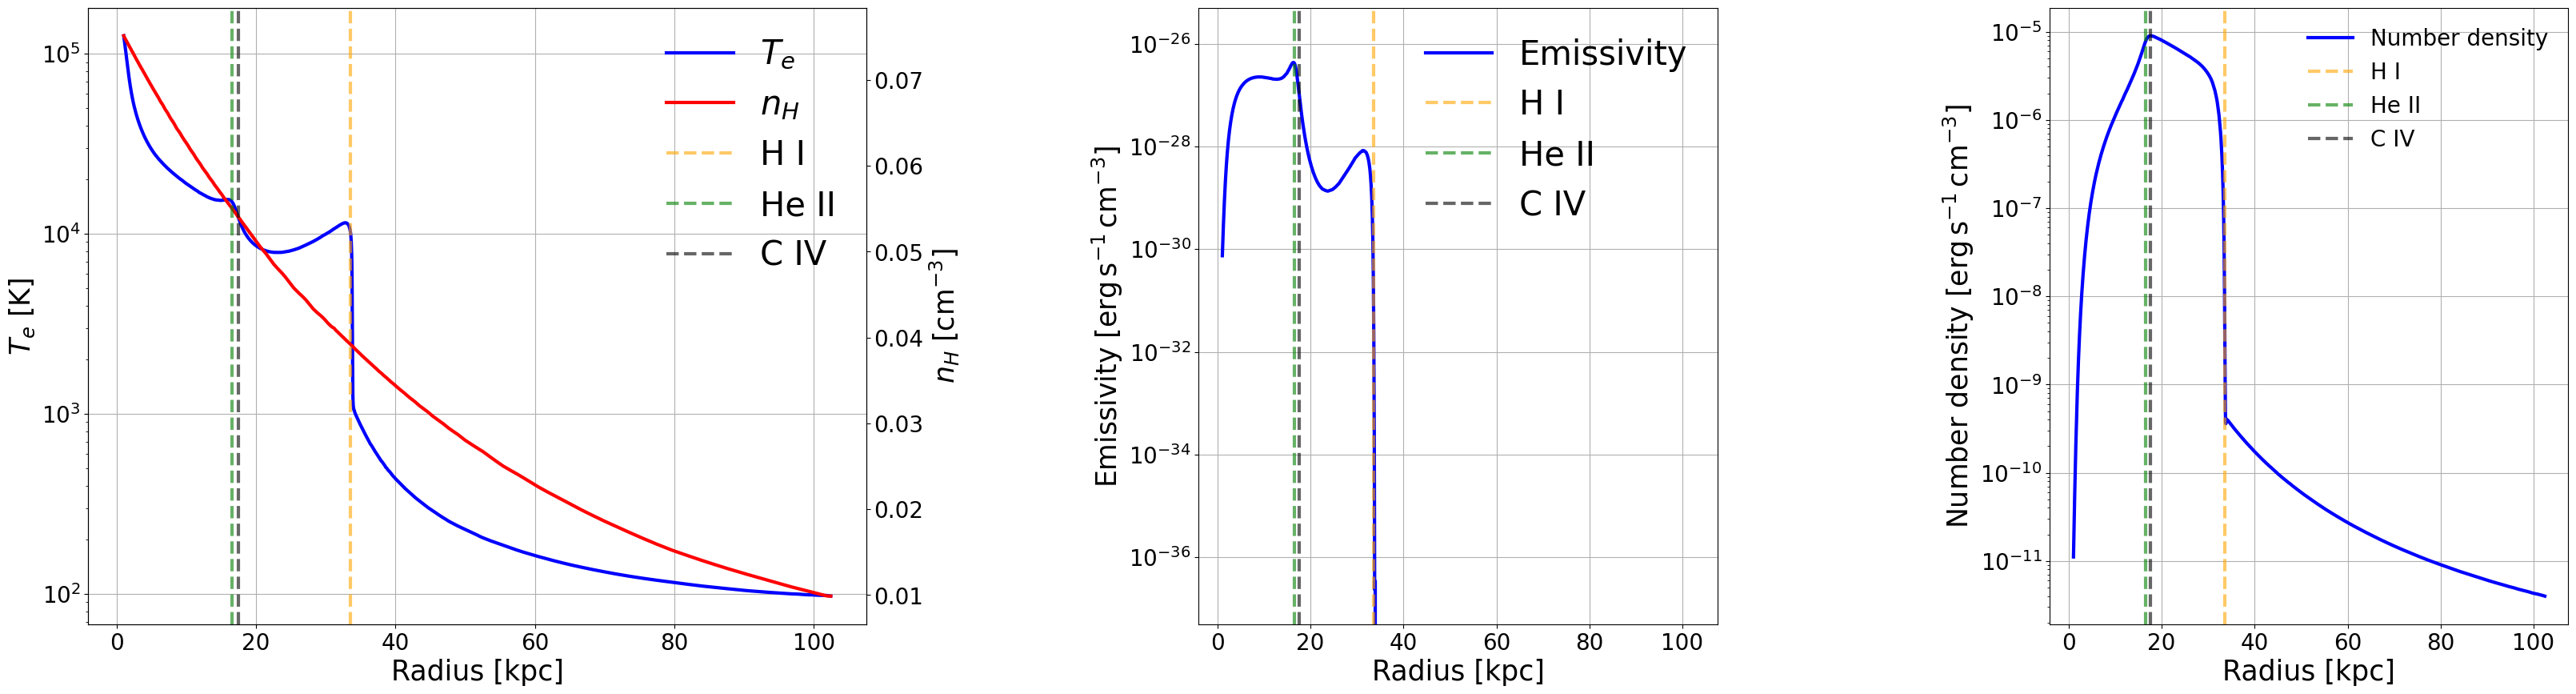

In [28]:
fig = plt.figure(figsize=(40, 10))
gs = gridspec.GridSpec(1, 3, width_ratios=[1.5, 1.0, 1.0], wspace=0.55) 

# width_ratios=[1, 1.2], wspace=0.55

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

Lum = 44

version = 1
N_H = 22.0
multi = 1
tur = 50.0

print(f'Lum = {Lum}')


version = 2
CLOUDY_data(Lum, N_H, version, multi)
# === 첫 번째 subplot ===

ax1a = ax1
ax1b = ax1a.twinx()

ax1a.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'Te_{Lum}_{version}'], 'b-',lw=3 ,label=r'$T_e$')
ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'nH_{Lum}_{version}'], 'r-',lw=3 ,label=r'$n_H$')

ax1b.axvline(x=33.5,ymin=0,ymax=1,linestyle='--',color='orange',alpha=0.6,lw=3,label='H I')
ax1b.axvline(x=16.5,ymin=0,ymax=1,linestyle='--',color='g',alpha=0.6,lw=3,label='He II')
ax1b.axvline(x=17.5,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.6,lw=3,label='C IV')

# ax1b.axvline(x=22,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.6,lw=3)

# ax1a.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'emis_HeII_{Lum}_{version}'], 'k-',lw=3 ,label=r'Emissivity') # , $\epsilon_{\rm CIV}$
# ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'nden_HeII_{Lum}_{version}'], 'k--', lw=3, label=r'Number density')


ax1a.grid(True)

ax1a.set_xlabel('Radius [kpc]', fontsize=25)
ax1a.set_ylabel(r'$T_e$ [K]', fontsize=25)
ax1b.set_ylabel(r'$n_H$ [$\rm cm^{-3}$]', fontsize=25)

ax1a.set_yscale('log')
# ax1b.set_yscale('log')

ax1a.tick_params(axis='both', labelsize=20)
ax1b.tick_params(axis='both', labelsize=20)
# ax1.set_ylim(5e-38,5e-26)
# ax1b.set_ylim(5e-14,5e-5)
# 범례 통합
lines1, labels1 = ax1a.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=30, frameon=False)

plt.tight_layout()




ax2.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'emis_CIV_{Lum}_{version}'], 'b-',lw=3 ,label=r'Emissivity') # , $\epsilon_{\rm CIV}$


ax2.axvline(x=33.5,ymin=0,ymax=1,linestyle='--',color='orange',alpha=0.6,lw=3,label='H I')
ax2.axvline(x=16.5,ymin=0,ymax=1,linestyle='--',color='g',alpha=0.6,lw=3,label='He II')
ax2.axvline(x=17.5,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.6,lw=3,label='C IV')

# ax2.axvline(x=22,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.6,lw=3)
# ax1a.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'emis_HeII_{Lum}_{version}'], 'k-',lw=3 ,label=r'Emissivity') # , $\epsilon_{\rm CIV}$
# ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'nden_HeII_{Lum}_{version}'], 'k--', lw=3, label=r'Number density')


ax1.grid(True)

ax2.set_xlabel('Radius [kpc]', fontsize=25)
ax2.set_ylabel(r'Emissivity [$\rm erg \, s^{-1} \,cm^{-3}$]', fontsize=25)
ax2.set_yscale('log')
ax2.tick_params(axis='both', labelsize=20)
ax2.set_ylim(5e-38,5e-26)
ax2.legend(fontsize=30, frameon=False)

ax2.grid(True)




ax3.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'nden_CIV_{Lum}_{version}'], 'b-',lw=3 ,label=r'Number density') # , $\epsilon_{\rm CIV}$

ax3.axvline(x=33.5,ymin=0,ymax=1,linestyle='--',color='orange',alpha=0.6,lw=3,label='H I')
ax3.axvline(x=16.5,ymin=0,ymax=1,linestyle='--',color='g',alpha=0.6,lw=3,label='He II')
ax3.axvline(x=17.5,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.6,lw=3,label='C IV')

ax3.set_xlabel('Radius [kpc]', fontsize=25)
ax3.set_ylabel(r'Number density [$\rm erg \, s^{-1} \,cm^{-3}$]', fontsize=25)
# ax3.set_ylabel(r'Fraction', fontsize=25)

ax3.set_yscale('log')
ax3.tick_params(axis='both', labelsize=20)

ax3.legend(fontsize=20, frameon=False)
ax3.grid(True)
plt.tight_layout()





plt.tight_layout()

# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/ttt.png',bbox_inches="tight")

Lum = 45.5


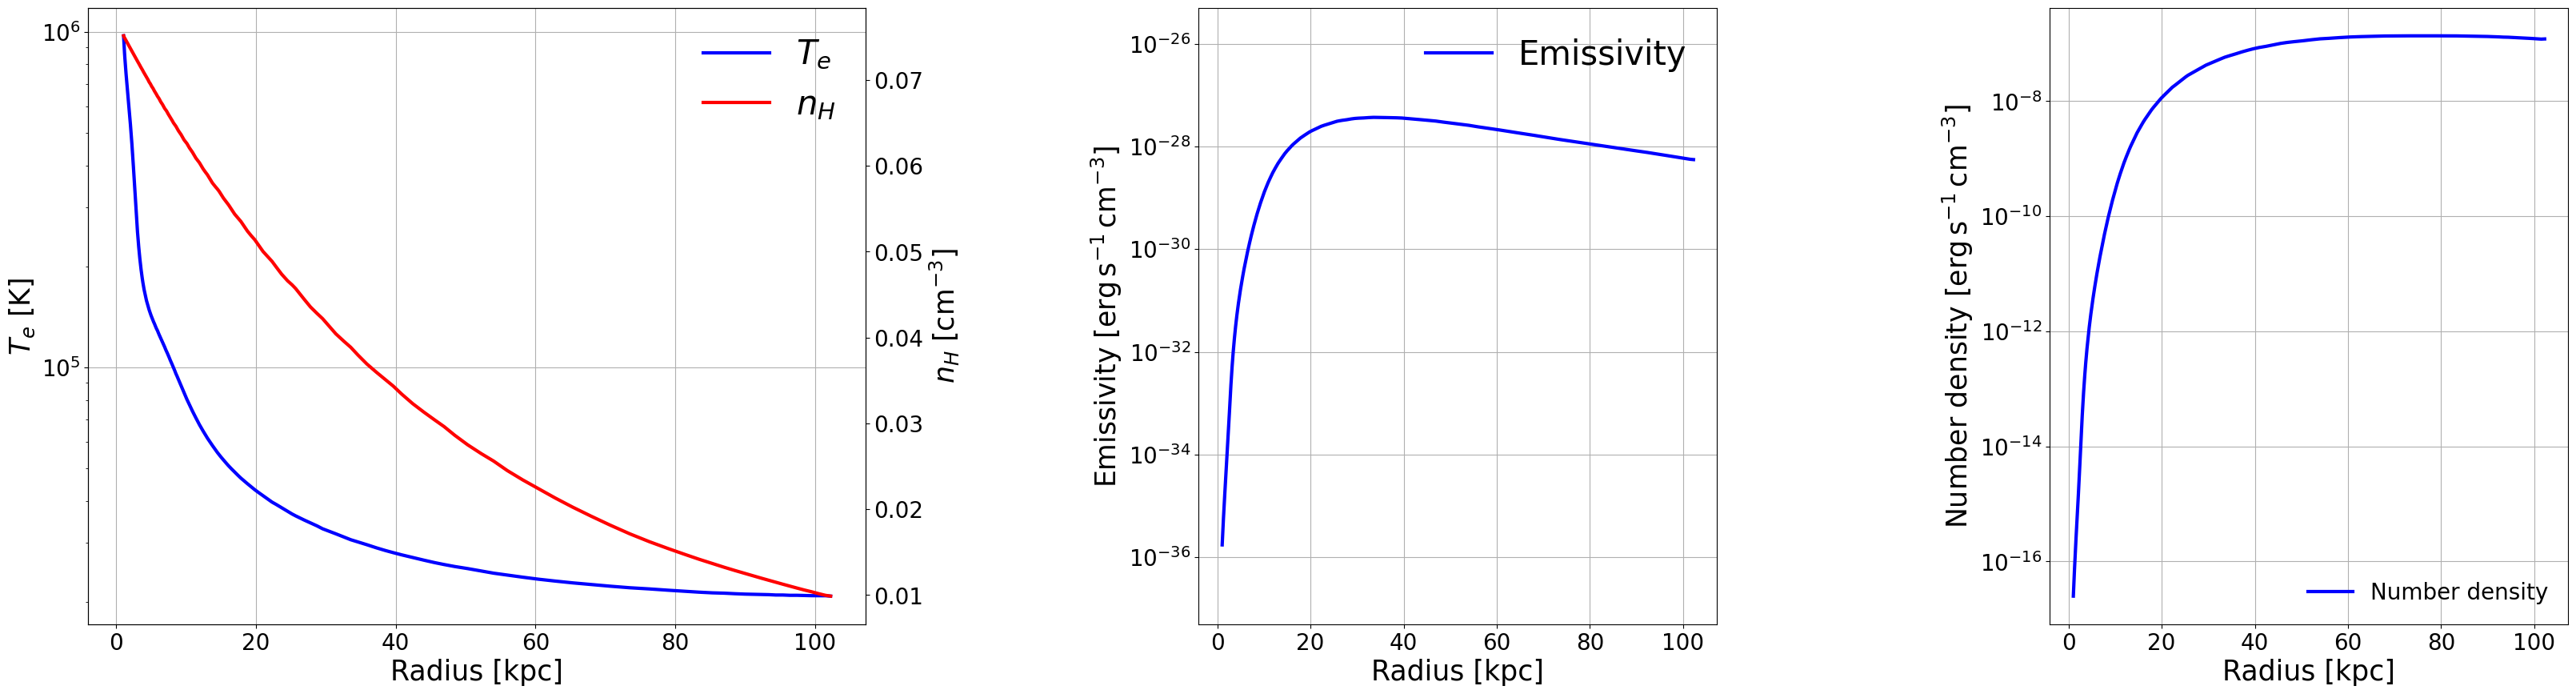

In [29]:
fig = plt.figure(figsize=(40, 10))
gs = gridspec.GridSpec(1, 3, width_ratios=[1.5, 1.0, 1.0], wspace=0.55) 

# width_ratios=[1, 1.2], wspace=0.55

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

Lum = 45.5

version = 1
N_H = 22.0
multi = 1
tur = 50.0

print(f'Lum = {Lum}')


version = 2
CLOUDY_data(Lum, N_H, version, multi)
# === 첫 번째 subplot ===

ax1a = ax1
ax1b = ax1a.twinx()

ax1a.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'Te_{Lum}_{version}'], 'b-',lw=3 ,label=r'$T_e$')
ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'nH_{Lum}_{version}'], 'r-',lw=3 ,label=r'$n_H$')

# ax1b.axvline(x=33.5,ymin=0,ymax=1,linestyle='--',color='orange',alpha=0.6,lw=3,label='H I')
# ax1b.axvline(x=16.5,ymin=0,ymax=1,linestyle='--',color='g',alpha=0.6,lw=3,label='He II')
# ax1b.axvline(x=17.5,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.6,lw=3,label='C IV')

# ax1b.axvline(x=22,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.6,lw=3)

# ax1a.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'emis_HeII_{Lum}_{version}'], 'k-',lw=3 ,label=r'Emissivity') # , $\epsilon_{\rm CIV}$
# ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'nden_HeII_{Lum}_{version}'], 'k--', lw=3, label=r'Number density')


ax1a.grid(True)

ax1a.set_xlabel('Radius [kpc]', fontsize=25)
ax1a.set_ylabel(r'$T_e$ [K]', fontsize=25)
ax1b.set_ylabel(r'$n_H$ [$\rm cm^{-3}$]', fontsize=25)

ax1a.set_yscale('log')
# ax1b.set_yscale('log')

ax1a.tick_params(axis='both', labelsize=20)
ax1b.tick_params(axis='both', labelsize=20)
# ax1.set_ylim(5e-38,5e-26)
# ax1b.set_ylim(5e-14,5e-5)
# 범례 통합
lines1, labels1 = ax1a.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=30, frameon=False)

plt.tight_layout()




ax2.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'emis_CIV_{Lum}_{version}'], 'b-',lw=3 ,label=r'Emissivity') # , $\epsilon_{\rm CIV}$


# ax2.axvline(x=33.5,ymin=0,ymax=1,linestyle='--',color='orange',alpha=0.6,lw=3,label='H I')
# ax2.axvline(x=16.5,ymin=0,ymax=1,linestyle='--',color='g',alpha=0.6,lw=3,label='He II')
# ax2.axvline(x=17.5,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.6,lw=3,label='C IV')

# ax2.axvline(x=22,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.6,lw=3)
# ax1a.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'emis_HeII_{Lum}_{version}'], 'k-',lw=3 ,label=r'Emissivity') # , $\epsilon_{\rm CIV}$
# ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'nden_HeII_{Lum}_{version}'], 'k--', lw=3, label=r'Number density')


ax1.grid(True)

ax2.set_xlabel('Radius [kpc]', fontsize=25)
ax2.set_ylabel(r'Emissivity [$\rm erg \, s^{-1} \,cm^{-3}$]', fontsize=25)
ax2.set_yscale('log')
ax2.tick_params(axis='both', labelsize=20)
ax2.set_ylim(5e-38,5e-26)
ax2.legend(fontsize=30, frameon=False)

ax2.grid(True)




ax3.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'nden_CIV_{Lum}_{version}'], 'b-',lw=3 ,label=r'Number density') # , $\epsilon_{\rm CIV}$

# ax3.axvline(x=33.5,ymin=0,ymax=1,linestyle='--',color='orange',alpha=0.6,lw=3,label='H I')
# ax3.axvline(x=16.5,ymin=0,ymax=1,linestyle='--',color='g',alpha=0.6,lw=3,label='He II')
# ax3.axvline(x=17.5,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.6,lw=3,label='C IV')

ax3.set_xlabel('Radius [kpc]', fontsize=25)
ax3.set_ylabel(r'Number density [$\rm erg \, s^{-1} \,cm^{-3}$]', fontsize=25)
# ax3.set_ylabel(r'Fraction', fontsize=25)

ax3.set_yscale('log')
ax3.tick_params(axis='both', labelsize=20)

ax3.legend(fontsize=20, frameon=False)
ax3.grid(True)
plt.tight_layout()





plt.tight_layout()

# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/ttt.png',bbox_inches="tight")

Lum = 44


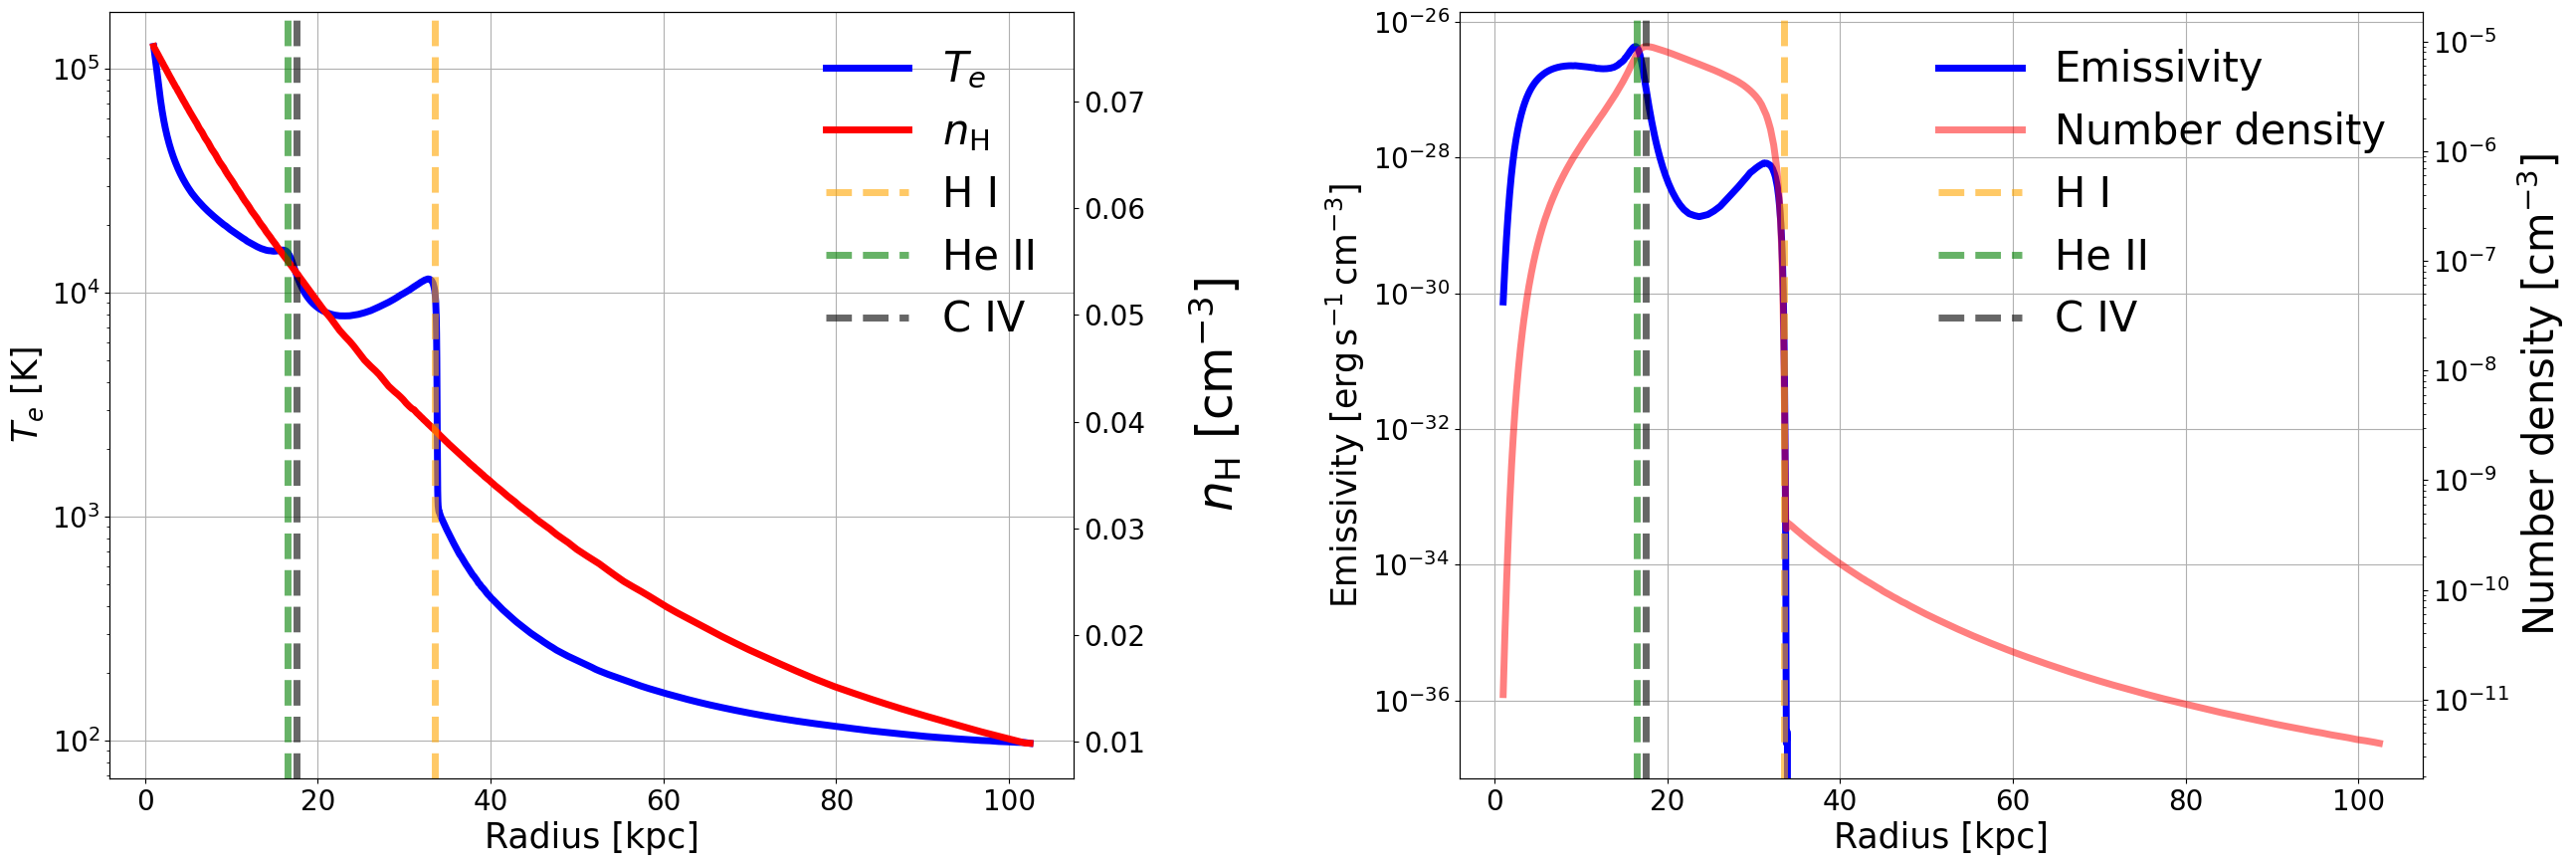

In [30]:
fig = plt.figure(figsize=(30, 10))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.0, 1.0], wspace=0.4) 

# width_ratios=[1, 1.2], wspace=0.55

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])


Lum = 44

version = 1
N_H = 22.0
multi = 1
tur = 50.0

print(f'Lum = {Lum}')


version = 2
CLOUDY_data(Lum, N_H, version, multi)
# === 첫 번째 subplot ===

ax1a = ax1
ax1b = ax1a.twinx()

ax1a.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'Te_{Lum}_{version}'], 'b-',lw=5 ,label=r'$T_e$')
ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'nH_{Lum}_{version}'], 'r-',lw=5 ,label=r'$n_{\rm H}$')

ax1b.axvline(x=33.5,ymin=0,ymax=1,linestyle='--',color='orange',alpha=0.6,lw=5,label='H I')
ax1b.axvline(x=16.5,ymin=0,ymax=1,linestyle='--',color='g',alpha=0.6,lw=5,label='He II')
ax1b.axvline(x=17.5,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.6,lw=5,label='C IV')

# ax1b.axvline(x=22,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.6,lw=3)

# ax1a.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'emis_HeII_{Lum}_{version}'], 'k-',lw=3 ,label=r'Emissivity') # , $\epsilon_{\rm CIV}$
# ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'nden_HeII_{Lum}_{version}'], 'k--', lw=3, label=r'Number density')


ax1a.grid(True)

ax1a.set_xlabel('Radius [kpc]', fontsize=25)
ax1a.set_ylabel(r'$T_e$ [K]', fontsize=25)
ax1b.set_ylabel(r'$n_{\rm H}$ [$\rm cm^{-3}$]', fontsize=35,labelpad=30)

ax1a.set_yscale('log')
# ax1b.set_yscale('log')

ax1a.tick_params(axis='both', labelsize=20)
ax1b.tick_params(axis='both', labelsize=20)
# ax1.set_ylim(5e-38,5e-26)
# ax1b.set_ylim(5e-14,5e-5)
# 범례 통합
lines1, labels1 = ax1a.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=30, frameon=False)
ax1.grid(True)
plt.tight_layout()

#------------------------axis 2 ------------------------------------------


ax2a = ax2
ax2b = ax2a.twinx()

ax2a.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'emis_CIV_{Lum}_{version}'], 'b-',lw=5,label=r'Emissivity') # , $\epsilon_{\rm CIV}$
ax2b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'nden_CIV_{Lum}_{version}'], 'r-',lw=5,alpha=0.5 ,label=r'Number density') # , $\epsilon_{\rm CIV}$


ax2b.axvline(x=33.5,ymin=0,ymax=1,linestyle='--',color='orange',alpha=0.6,lw=5,label='H I')
ax2b.axvline(x=16.5,ymin=0,ymax=1,linestyle='--',color='g',alpha=0.6,lw=5,label='He II')
ax2b.axvline(x=17.5,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.6,lw=5,label='C IV')

# ax2.axvline(x=22,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.6,lw=3)
# ax1a.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'emis_HeII_{Lum}_{version}'], 'k-',lw=3 ,label=r'Emissivity') # , $\epsilon_{\rm CIV}$
# ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'nden_HeII_{Lum}_{version}'], 'k--', lw=3, label=r'Number density')


ax2.grid(True)

ax2a.set_xlabel('Radius [kpc]', fontsize=25)
ax2a.set_ylabel(r'Emissivity [$\rm erg \, s^{-1} \,cm^{-3}$]', fontsize=25)
ax2b.set_ylabel(r'Number density [$\rm cm^{-3}$]', fontsize=30)
ax2a.set_yscale('log')
ax2b.set_yscale('log')
ax2a.tick_params(axis='both', labelsize=20)
ax2b.tick_params(axis='both', labelsize=20)
# ax2a.set_ylim(5e-38,5e-26)
ax2a.legend(fontsize=30, frameon=False)

ax2.grid(True)

lines1, labels1 = ax2a.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=30, frameon=False)



plt.tight_layout()

# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/ttt.png',bbox_inches="tight")

Lum = 45.5


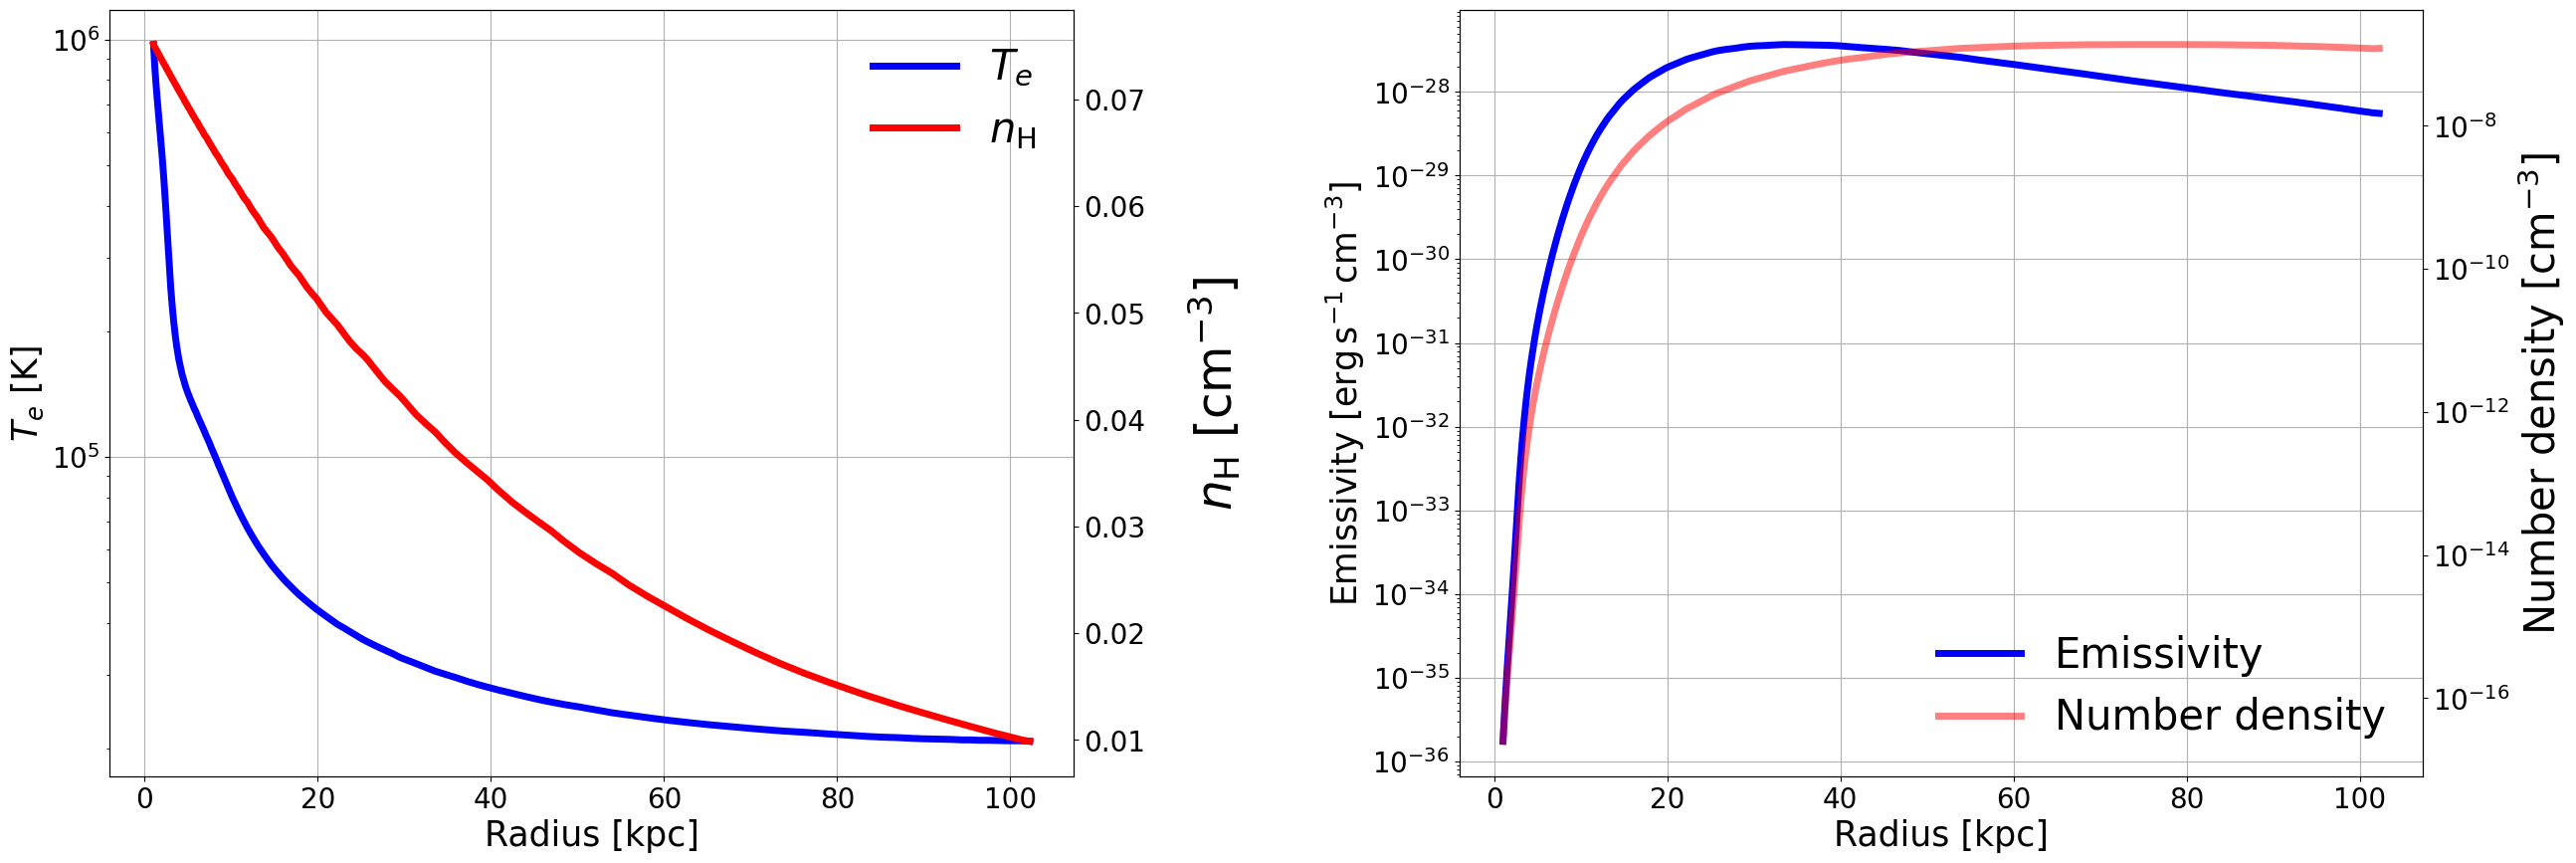

In [31]:
fig = plt.figure(figsize=(30, 10))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.0, 1.0], wspace=0.4) 

# width_ratios=[1, 1.2], wspace=0.55

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])


Lum = 45.5

version = 1
N_H = 22.0
multi = 1
tur = 50.0

print(f'Lum = {Lum}')


version = 2
CLOUDY_data(Lum, N_H, version, multi)
# === 첫 번째 subplot ===

ax1a = ax1
ax1b = ax1a.twinx()

ax1a.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'Te_{Lum}_{version}'], 'b-',lw=5 ,label=r'$T_e$')
ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'nH_{Lum}_{version}'], 'r-',lw=5 ,label=r'$n_{\rm H}$')

# ax1b.axvline(x=33.5,ymin=0,ymax=1,linestyle='--',color='orange',alpha=0.6,lw=5,label='H I')
# ax1b.axvline(x=16.5,ymin=0,ymax=1,linestyle='--',color='g',alpha=0.6,lw=5,label='He II')
# ax1b.axvline(x=17.5,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.6,lw=5,label='C IV')

# ax1b.axvline(x=22,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.6,lw=3)

# ax1a.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'emis_HeII_{Lum}_{version}'], 'k-',lw=3 ,label=r'Emissivity') # , $\epsilon_{\rm CIV}$
# ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'nden_HeII_{Lum}_{version}'], 'k--', lw=3, label=r'Number density')


ax1a.grid(True)

ax1a.set_xlabel('Radius [kpc]', fontsize=25)
ax1a.set_ylabel(r'$T_e$ [K]', fontsize=25)
ax1b.set_ylabel(r'$n_{\rm H}$ [$\rm cm^{-3}$]', fontsize=35,labelpad=30)

ax1a.set_yscale('log')
# ax1b.set_yscale('log')

ax1a.tick_params(axis='both', labelsize=20)
ax1b.tick_params(axis='both', labelsize=20)
# ax1.set_ylim(5e-38,5e-26)
# ax1b.set_ylim(5e-14,5e-5)
# 범례 통합
lines1, labels1 = ax1a.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=30, frameon=False)
ax1.grid(True)
plt.tight_layout()

#------------------------axis 2 ------------------------------------------


ax2a = ax2
ax2b = ax2a.twinx()

ax2a.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'emis_CIV_{Lum}_{version}'], 'b-',lw=5,label=r'Emissivity') # , $\epsilon_{\rm CIV}$
ax2b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'nden_CIV_{Lum}_{version}'], 'r-',lw=5,alpha=0.5 ,label=r'Number density') # , $\epsilon_{\rm CIV}$


# ax2b.axvline(x=33.5,ymin=0,ymax=1,linestyle='--',color='orange',alpha=0.6,lw=5,label='H I')
# ax2b.axvline(x=16.5,ymin=0,ymax=1,linestyle='--',color='g',alpha=0.6,lw=5,label='He II')
# ax2b.axvline(x=17.5,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.6,lw=5,label='C IV')

# ax2.axvline(x=22,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.6,lw=3)
# ax1a.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'emis_HeII_{Lum}_{version}'], 'k-',lw=3 ,label=r'Emissivity') # , $\epsilon_{\rm CIV}$
# ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'nden_HeII_{Lum}_{version}'], 'k--', lw=3, label=r'Number density')


ax2.grid(True)

ax2a.set_xlabel('Radius [kpc]', fontsize=25)
ax2a.set_ylabel(r'Emissivity [$\rm erg \, s^{-1} \,cm^{-3}$]', fontsize=25)
ax2b.set_ylabel(r'Number density [$\rm cm^{-3}$]', fontsize=30)
ax2a.set_yscale('log')
ax2b.set_yscale('log')
ax2a.tick_params(axis='both', labelsize=20)
ax2b.tick_params(axis='both', labelsize=20)
# ax2a.set_ylim(5e-38,5e-26)
ax2a.legend(fontsize=30, frameon=False)

ax2.grid(True)

lines1, labels1 = ax2a.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=30, frameon=False)



plt.tight_layout()

# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/ttt.png',bbox_inches="tight")

Lum = 44
Lum = 45.5


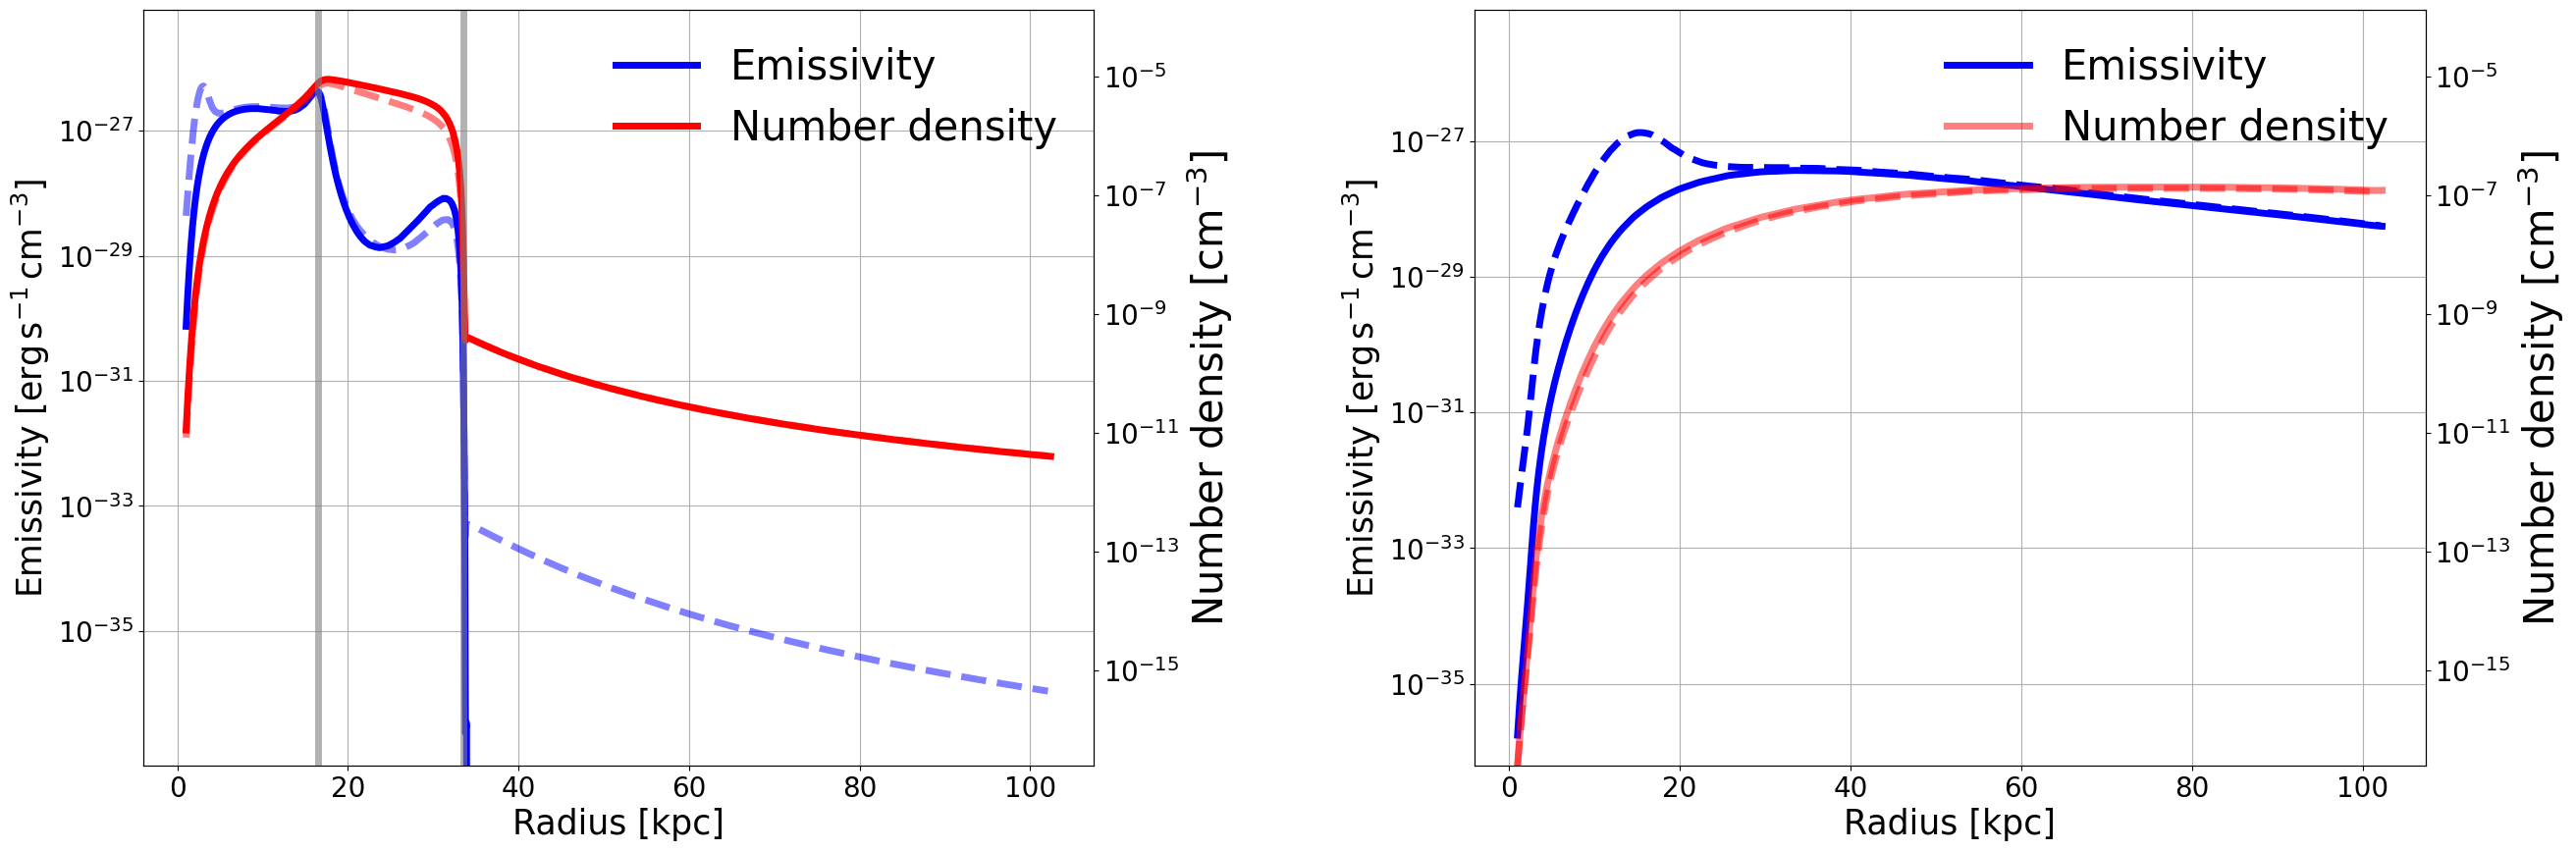

In [32]:
fig = plt.figure(figsize=(30, 10))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.0, 1.0], wspace=0.4) 

# width_ratios=[1, 1.2], wspace=0.55

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])


Lum = 44

version = 1
N_H = 22.0
multi = 1
tur = 50.0

print(f'Lum = {Lum}')



# === 첫 번째 subplot ===


version = 1
CLOUDY_data(Lum, N_H, version, multi)
# === 첫 번째 subplot ===

ax1a = ax1
ax1b = ax1a.twinx()

ax1a.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'emis_CIV_{Lum}_{version}'], 'b--',alpha=0.5,lw=5) # , $\epsilon_{\rm CIV}$
ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'nden_CIV_{Lum}_{version}'], 'r--',lw=5,alpha=0.5) # , $\epsilon_{\rm CIV}$


version = 2
CLOUDY_data(Lum, N_H, version, multi)
ax1a.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'emis_CIV_{Lum}_{version}'], 'b-',lw=5,label=r'Emissivity') # , $\epsilon_{\rm CIV}$
ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'nden_CIV_{Lum}_{version}'], 'r-',lw=5,alpha=1 ,label=r'Number density') # , $\epsilon_{\rm CIV}$




ax1b.axvline(x=33.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)
ax1b.axvline(x=16.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)
# ax1b.axvline(x=17.5,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.6,lw=5,label='C IV')

# ax1b.axvline(x=22,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.6,lw=3)

# ax1a.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'emis_HeII_{Lum}_{version}'], 'k-',lw=3 ,label=r'Emissivity') # , $\epsilon_{\rm CIV}$
# ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'nden_HeII_{Lum}_{version}'], 'k--', lw=3, label=r'Number density')


ax1a.grid(True)

ax1a.set_xlabel('Radius [kpc]', fontsize=25)
ax1a.set_ylabel(r'Emissivity [$\rm erg \, s^{-1} \,cm^{-3}$]', fontsize=25)
ax1b.set_ylabel(r'Number density [$\rm cm^{-3}$]', fontsize=30)
ax1a.set_yscale('log')
ax1b.set_yscale('log')
ax1a.tick_params(axis='both', labelsize=20)
ax1b.tick_params(axis='both', labelsize=20)


yticks = [1e-27, 1e-29,1e-31,1e-33,1e-35]
ax1a.set_yticks(yticks)

# ax1.set_ylim(5e-38,5e-26)
# ax1b.set_ylim(5e-14,5e-5)
# 범례 통합
lines1, labels1 = ax1a.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=30, frameon=False)
ax1.grid(True)
plt.tight_layout()

#------------------------axis 2 ------------------------------------------

Lum = 45.5
CLOUDY_data(Lum, N_H, version, multi)
print(f'Lum = {Lum}')
ax2a = ax2
ax2b = ax2a.twinx()

ax2a.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'emis_CIV_{Lum}_{version}'], 'b-',lw=5,label=r'Emissivity') # , $\epsilon_{\rm CIV}$
ax2b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'nden_CIV_{Lum}_{version}'], 'r-',lw=5,alpha=0.5 ,label=r'Number density') # , $\epsilon_{\rm CIV}$

version = 1
CLOUDY_data(Lum, N_H, version, multi)
ax2a.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'emis_CIV_{Lum}_{version}'], 'b--',lw=5) # , $\epsilon_{\rm CIV}$
ax2b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'nden_CIV_{Lum}_{version}'], 'r--',lw=5,alpha=0.5) # , $\epsilon_{\rm CIV}$

# ax2b.axvline(x=33.5,ymin=0,ymax=1,linestyle='--',color='orange',alpha=0.6,lw=5,label='H I')
# ax2b.axvline(x=16.5,ymin=0,ymax=1,linestyle='--',color='g',alpha=0.6,lw=5,label='He II')
# ax2b.axvline(x=17.5,ymin=0,ymax=1,linestyle='--',color='k',alpha=0.6,lw=5,label='C IV')

# ax2.axvline(x=22,ymin=0,ymax=1,linestyle='-',color='k',alpha=0.6,lw=3)
# ax1a.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'emis_HeII_{Lum}_{version}'], 'k-',lw=3 ,label=r'Emissivity') # , $\epsilon_{\rm CIV}$
# ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'nden_HeII_{Lum}_{version}'], 'k--', lw=3, label=r'Number density')


ax2.grid(True)

ax2a.set_xlabel('Radius [kpc]', fontsize=25)
ax2a.set_ylabel(r'Emissivity [$\rm erg \, s^{-1} \,cm^{-3}$]', fontsize=25)
ax2b.set_ylabel(r'Number density [$\rm cm^{-3}$]', fontsize=30)
ax2a.set_yscale('log')
ax2b.set_yscale('log')
ax2a.tick_params(axis='both', labelsize=20)
ax2b.tick_params(axis='both', labelsize=20)
# ax2a.set_ylim(5e-38,5e-26)
ax2a.legend(fontsize=30, frameon=False)

yticks = [1e-27, 1e-29,1e-31,1e-33,1e-35]
ax2a.set_yticks(yticks)
ax2.grid(True)

lines1, labels1 = ax2a.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, fontsize=30, frameon=False)



plt.tight_layout()
ymin_a = min(np.min(globals()[f'emis_CIV_{44}_{2}']), np.min(globals()[f'emis_CIV_{45.5}_{2}']))
ymax_a = max(np.max(globals()[f'emis_CIV_{44}_{2}'])*20, np.max(globals()[f'emis_CIV_{45.5}_{2}'])*20)

ymin_b = min(np.min(globals()[f'nden_CIV_{44}_{2}']), np.min(globals()[f'nden_CIV_{45.5}_{2}']))
ymax_b = max(np.max(globals()[f'nden_CIV_{44}_{2}'])*15, np.max(globals()[f'nden_CIV_{45.5}_{2}'])*15)

# y축 범위 맞추기
ax1a.set_ylim(ymin_a, ymax_a)
ax2a.set_ylim(ymin_a, ymax_a)

ax1b.set_ylim(ymin_b, ymax_b)
ax2b.set_ylim(ymin_b, ymax_b)


# y축 tick 직접 지정

# y축 포맷터 통일
# from matplotlib.ticker import LogFormatterExponent
# formatter = LogFormatterExponent(base=10)
# ax1a.yaxis.set_major_formatter(formatter)
# ax2a.yaxis.set_major_formatter(formatter)

plt.tight_layout()

# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/appendix_CLOUDY.pdf',bbox_inches="tight")

Lum = 44
ax1 CIV range: 0.00e+00 ~ 4.32e-27
ax2 CIV range: 1.75e-36 ~ 3.68e-28


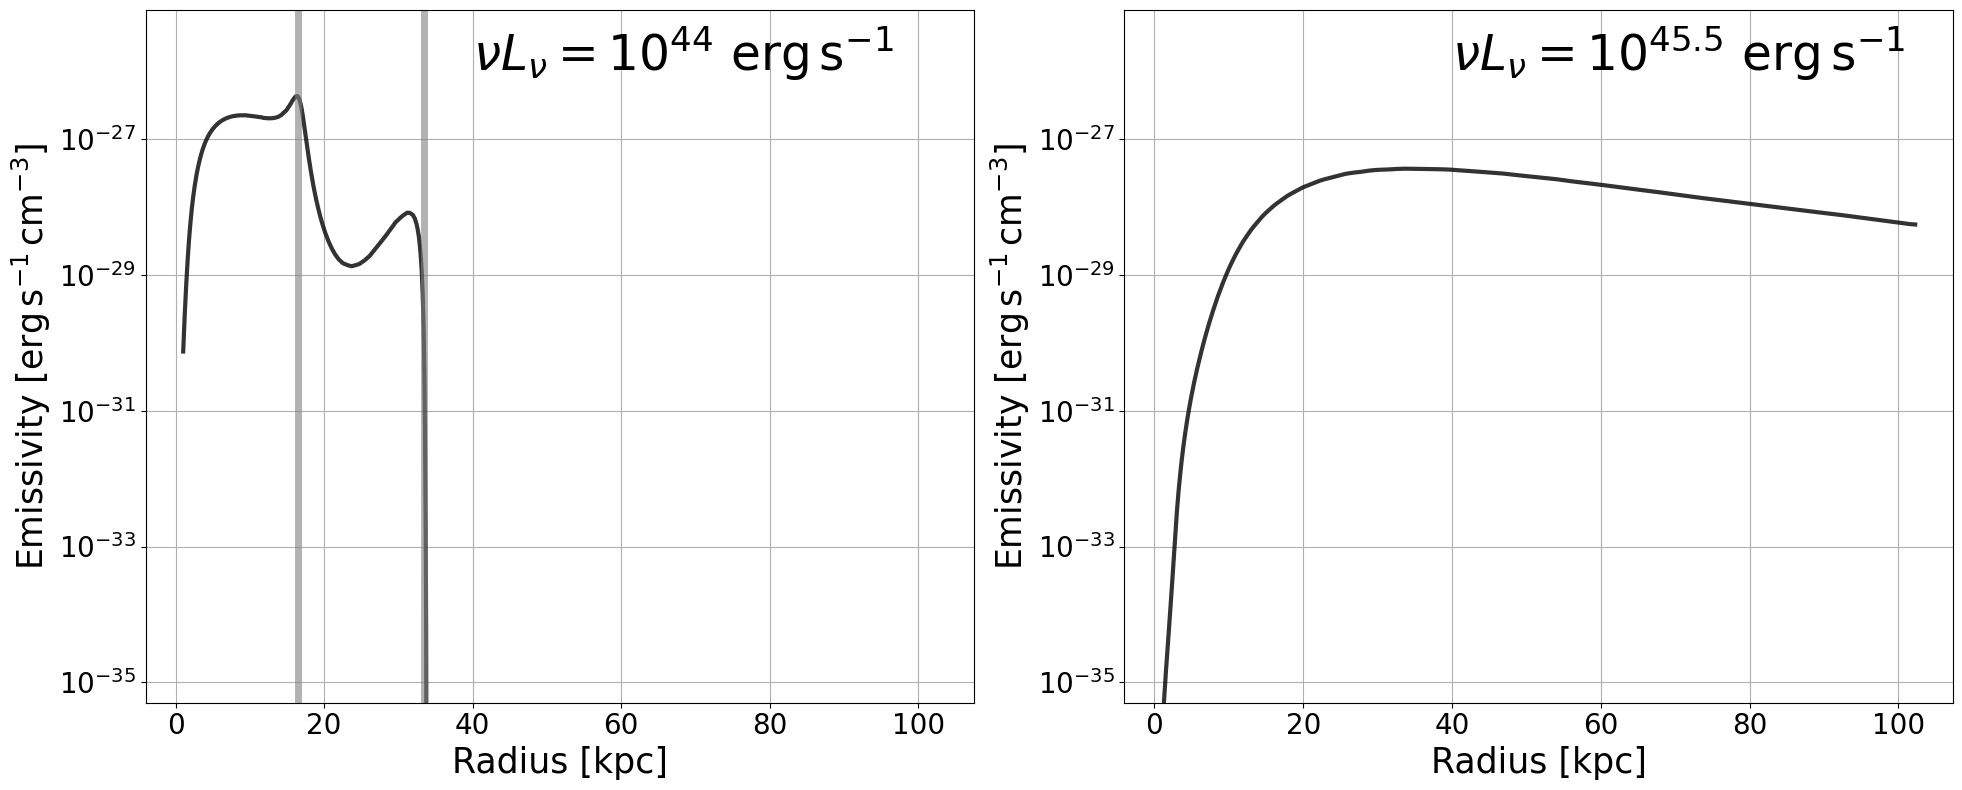

In [33]:
fig = plt.figure(figsize=(20, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.0, 1.0]) # , wspace=0.4 

# width_ratios=[1, 1.2], wspace=0.55

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])


Lum = 44

version = 1
N_H = 22.0
multi = 1
tur = 50.0

print(f'Lum = {Lum}')



# === 첫 번째 subplot ===


version = 2
CLOUDY_data(Lum, N_H, version, multi)
# heii_line = ax1.plot(
#     globals()[f'radius_{Lum}_{version}'], 
#     globals()[f'emis_HeII_{Lum}_{version}'], 
#     '--',color='k',alpha=0.8,lw=3, label='He II'
# )[0]

version = 2
CLOUDY_data(Lum, N_H, version, multi)
civ_line = ax1.plot(
    globals()[f'radius_{Lum}_{version}'], 
    globals()[f'emis_CIV_{Lum}_{version}'], 
    'k-',alpha=0.8,lw=3, label='C IV'
)[0]
# ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'nden_CIV_{Lum}_{version}'], 'r-',lw=5,alpha=1 ,label=r'Number density') # , $\epsilon_{\rm CIV}$




ax1.axvline(x=33.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)
ax1.axvline(x=16.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)

ax1.grid(True)

ax1.set_xlabel('Radius [kpc]', fontsize=25)
ax1.set_ylabel(r'Emissivity [$\rm erg \, s^{-1} \,cm^{-3}$]', fontsize=25)
ax1.set_yscale('log')
ax1.tick_params(axis='both', labelsize=20)


yticks = [1e-27, 1e-29,1e-31,1e-33,1e-35]

ax1.set_yticks(yticks)
ymin_a  = 5e-36  # 하한을 조금 더 낮게
ymax_b  = 8e-26  # 상한을 조금 더 높게

ax1.set_ylim(ymin_a, ymax_b)

# ax1.legend(fontsize=30, frameon=False,title='Emissivity',title_fontsize=30)
ax1.grid(True)

#------------------------axis 2 ------------------------------------------

Lum = 45.5

version = 2
# CLOUDY_data(Lum, N_H, version, multi)
# heii_line = ax2.plot(
#     globals()[f'radius_{Lum}_{version}'], 
#     globals()[f'emis_HeII_{Lum}_{version}'], 
#     '--',color='k',alpha=0.8,lw=3, label='He II'
# )[0]

version = 2
CLOUDY_data(Lum, N_H, version, multi)
civ_line = ax2.plot(
    globals()[f'radius_{Lum}_{version}'], 
    globals()[f'emis_CIV_{Lum}_{version}'], 
    'k-',alpha=0.8,lw=3, label='C IV'
)[0]
# ax2.axvline(x=33.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)
# ax2.axvline(x=16.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)
ax2.grid(True)

ax2.set_xlabel('Radius [kpc]', fontsize=25)
ax2.set_ylabel(r'Emissivity [$\rm erg \, s^{-1} \,cm^{-3}$]', fontsize=25)

ax2.set_yscale('log')

ax2.tick_params(axis='both', labelsize=20)
# ax2a.set_ylim(5e-38,5e-26)
# ax2.legend(fontsize=30, frameon=False)

ax1.text(40,1e-26,s=r'$\nu L_{\nu} = 10^{44}~{\rm erg \, s^{-1}}$',fontsize=35,weight='bold')
ax2.text(40,1e-26,s=r'$\nu L_{\nu} = 10^{45.5}~{\rm erg \, s^{-1}}$',fontsize=35,weight='bold')
# yticks = [1e-27, 1e-29,1e-31,1e-33,1e-35]
# ax2.set_yticks(yticks)
ax2.grid(True)

yticks = [1e-27, 1e-29,1e-31,1e-33,1e-35]

ax2.set_yticks(yticks)
# ax2.legend(fontsize=30, frameon=False,title='Emissivity',title_fontsize=30)


print(f"ax1 CIV range: {np.min(globals()[f'emis_CIV_{44}_{2}']):.2e} ~ {np.max(globals()[f'emis_CIV_{44}_{2}']):.2e}")
print(f"ax2 CIV range: {np.min(globals()[f'emis_CIV_{45.5}_{2}']):.2e} ~ {np.max(globals()[f'emis_CIV_{45.5}_{2}']):.2e}")

# 더 정확한 범위 계산
ymin_a = min(np.min(globals()[f'emis_CIV_{44}_{2}']), np.min(globals()[f'emis_CIV_{45.5}_{2}']))
ymax_b = max(np.max(globals()[f'emis_CIV_{44}_{2}']), np.max(globals()[f'emis_CIV_{45.5}_{2}']))

# 약간의 여백 추가
ymin_a  = 5e-36  # 하한을 조금 더 낮게
ymax_b  = 8e-26  # 상한을 조금 더 높게

ax2.set_ylim(ymin_a, ymax_b)

plt.tight_layout()

# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Emissivity_by_CLOUDY.pdf',bbox_inches="tight")


Lum = 44
ax1 CIV range: 3.99e-12 ~ 8.98e-06
ax2 CIV range: 2.49e-17 ~ 1.37e-07


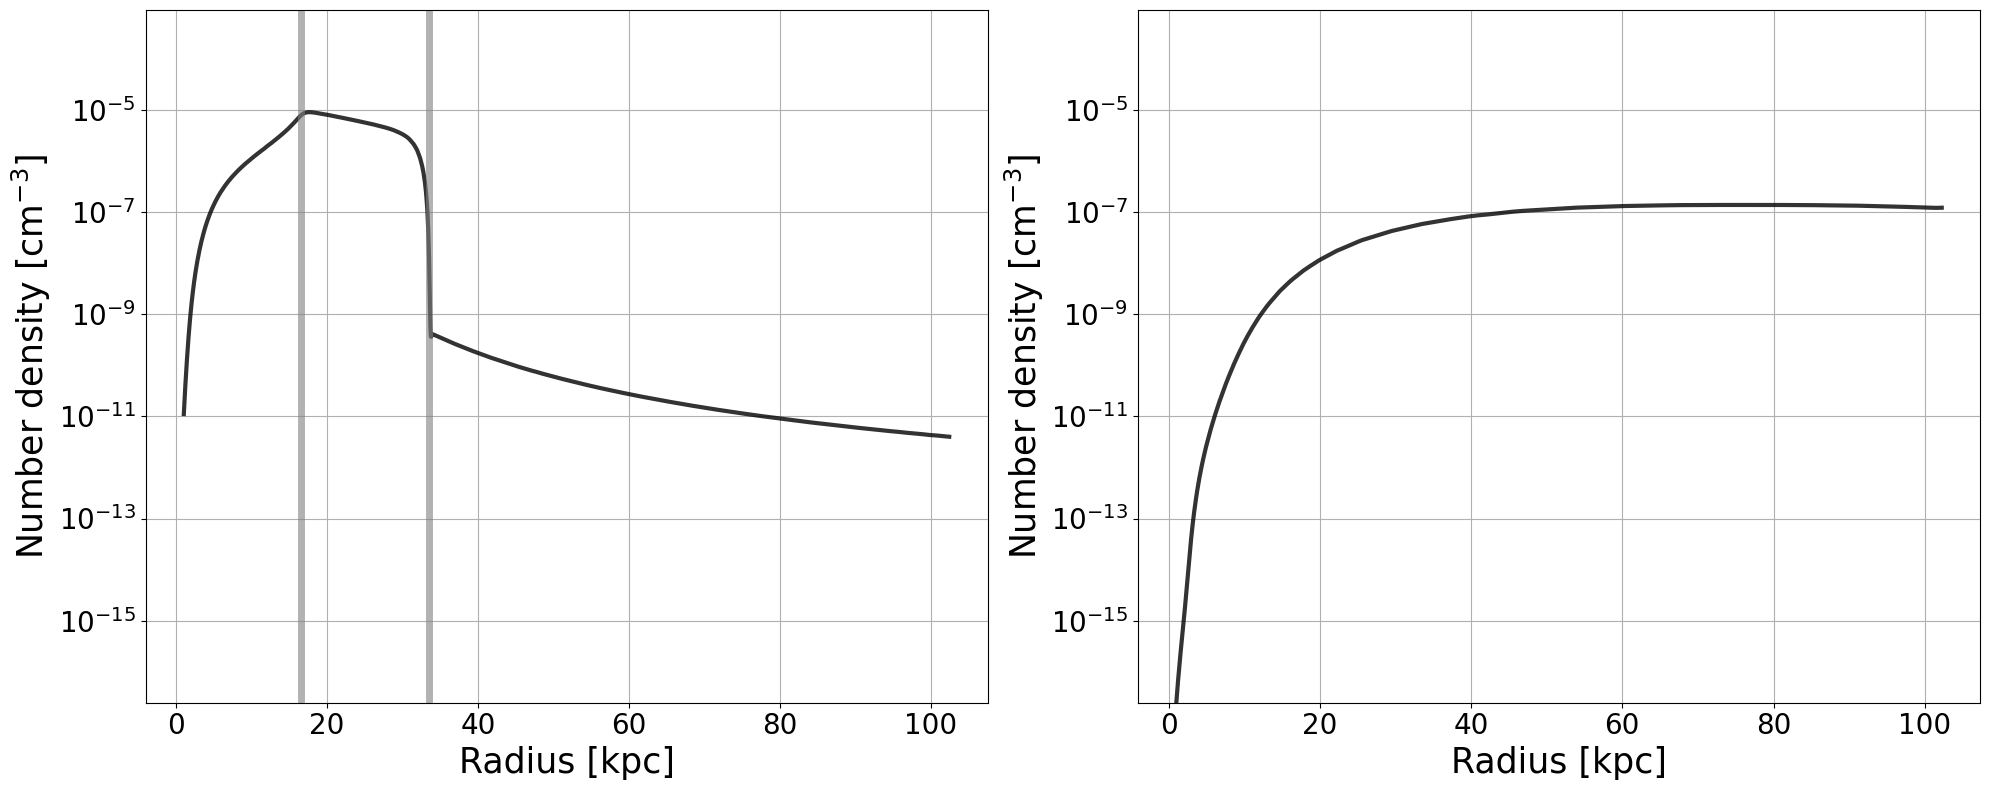

In [34]:
fig = plt.figure(figsize=(20, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.0, 1.0]) # , wspace=0.4 

# width_ratios=[1, 1.2], wspace=0.55

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])


Lum = 44

version = 1
N_H = 22.0
multi = 1
tur = 50.0

print(f'Lum = {Lum}')



# === 첫 번째 subplot ===


version = 2
CLOUDY_data(Lum, N_H, version, multi)
# heii_line = ax1.plot(
#     globals()[f'radius_{Lum}_{version}'], 
#     globals()[f'nden_HeII_{Lum}_{version}'], 
#     '--',color='k',alpha=0.8,lw=3, label='He II'
# )[0]

version = 2
CLOUDY_data(Lum, N_H, version, multi)
civ_line = ax1.plot(
    globals()[f'radius_{Lum}_{version}'], 
    globals()[f'nden_CIV_{Lum}_{version}'], 
    'k-',alpha=0.8,lw=3, label='C IV'
)[0]
# ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'nden_CIV_{Lum}_{version}'], 'r-',lw=5,alpha=1 ,label=r'Number density') # , $\epsilon_{\rm CIV}$




ax1.axvline(x=33.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)
ax1.axvline(x=16.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)

ax1.grid(True)

ax1.set_xlabel('Radius [kpc]', fontsize=25)
ax1.set_ylabel(r'Number density [$\rm cm^{-3}$]', fontsize=25)
ax1.set_yscale('log')
ax1.tick_params(axis='both', labelsize=20)


# yticks = [1e-27, 1e-29,1e-31,1e-33,1e-35]

# ax1.set_yticks(yticks)
# ymin_a  = 5e-36  # 하한을 조금 더 낮게
# ymax_b  = 8e-26  # 상한을 조금 더 높게



# ax1.legend(fontsize=30, frameon=False,title='Number density',title_fontsize=30)
ax1.grid(True)

#------------------------axis 2 ------------------------------------------

Lum = 45.5

version = 2
# CLOUDY_data(Lum, N_H, version, multi)
# heii_line = ax2.plot(
#     globals()[f'radius_{Lum}_{version}'], 
#     globals()[f'nden_HeII_{Lum}_{version}'], 
#     '--',color='k',alpha=0.8,lw=3, label='He II'
# )[0]

version = 2
CLOUDY_data(Lum, N_H, version, multi)
civ_line = ax2.plot(
    globals()[f'radius_{Lum}_{version}'], 
    globals()[f'nden_CIV_{Lum}_{version}'], 
    'k-',alpha=0.8,lw=3, label='C IV'
)[0]
# ax2.axvline(x=33.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)
# ax2.axvline(x=16.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)
ax2.grid(True)

ax2.set_xlabel('Radius [kpc]', fontsize=25)
ax2.set_ylabel(r'Number density [$\rm cm^{-3}$]', fontsize=25)

ax2.set_yscale('log')

ax2.tick_params(axis='both', labelsize=20)
# ax2a.set_ylim(5e-38,5e-26)
# ax2.legend(fontsize=30, frameon=False)
# ax1.text(3,0.5e-4,s=r'$\nu L_{\nu} = 10^{44}~{\rm erg \, s^{-1}}$',fontsize=35,weight='bold')
# ax2.text(3,0.5e-4,s=r'$\nu L_{\nu} = 10^{45.5}~{\rm erg \, s^{-1}}$',fontsize=35,weight='bold')
# yticks = [1e-27, 1e-29,1e-31,1e-33,1e-35]
# ax2.set_yticks(yticks)
ax2.grid(True)

# yticks = [1e-27, 1e-29,1e-31,1e-33,1e-35]

# ax2.set_yticks(yticks)
# ax2.legend(fontsize=30, frameon=False,title='Number density',title_fontsize=30)


print(f"ax1 CIV range: {np.min(globals()[f'nden_CIV_{44}_{2}']):.2e} ~ {np.max(globals()[f'nden_CIV_{44}_{2}']):.2e}")
print(f"ax2 CIV range: {np.min(globals()[f'nden_CIV_{45.5}_{2}']):.2e} ~ {np.max(globals()[f'nden_CIV_{45.5}_{2}']):.2e}")

# 더 정확한 범위 계산
ymin_a = min(np.min(globals()[f'nden_CIV_{44}_{2}']), np.min(globals()[f'nden_CIV_{45.5}_{2}']))
ymax_b = max(np.max(globals()[f'nden_CIV_{44}_{2}']), np.max(globals()[f'nden_CIV_{45.5}_{2}']))

# 약간의 여백 추가
# ymin_a  = 5e-36  # 하한을 조금 더 낮게
# ymax_b  = 8e-26  # 상한을 조금 더 높게
ax1.set_ylim(ymin_a, ymax_b*100)
ax2.set_ylim(ymin_a, ymax_b*100)

plt.tight_layout()

# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Number_density_by_CLOUDY.pdf',bbox_inches="tight")


Lum = 44


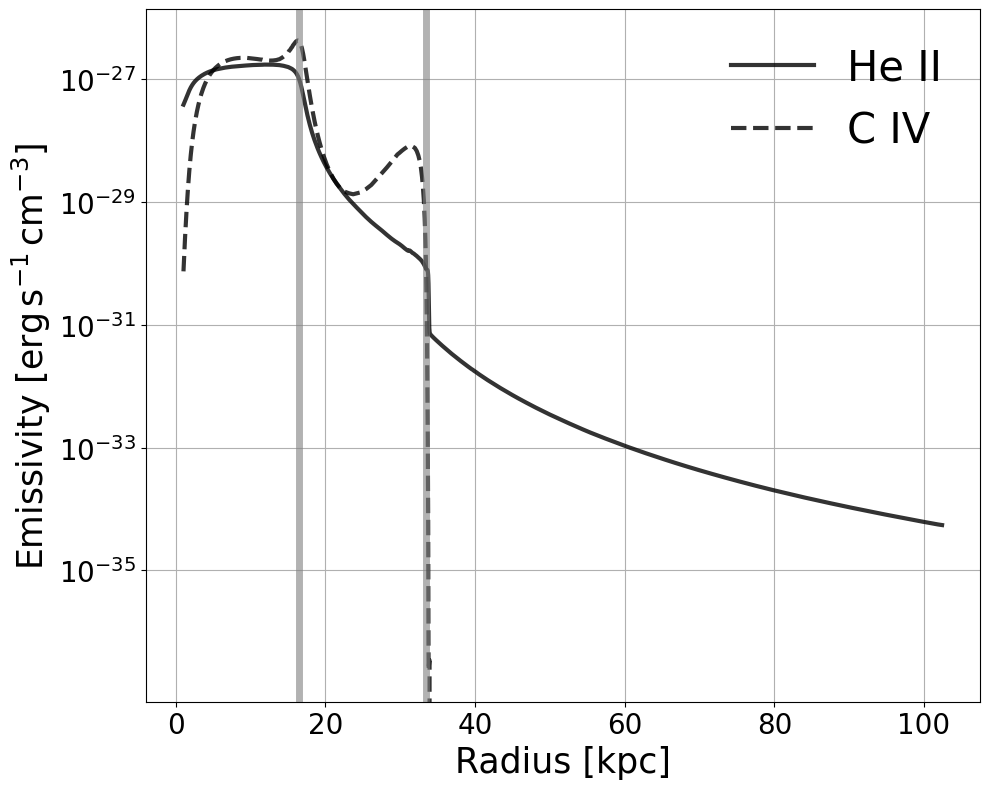

In [35]:
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(1, 1) # , wspace=0.4 

# width_ratios=[1, 1.2], wspace=0.55

ax1 = fig.add_subplot(gs[0])


Lum = 44

version = 1
N_H = 22.0
multi = 1
tur = 50.0

print(f'Lum = {Lum}')



# === 첫 번째 subplot ===



version = 2
CLOUDY_data(Lum, N_H, version, multi)
heii_line = ax1.plot(
    globals()[f'radius_{Lum}_{version}'], 
    globals()[f'emis_HeII_{Lum}_{version}'], 
    '-',color='k',alpha=0.8,lw=3, label='He II'
)[0]

version = 2
CLOUDY_data(Lum, N_H, version, multi)
civ_line = ax1.plot(
    globals()[f'radius_{Lum}_{version}'], 
    globals()[f'emis_CIV_{Lum}_{version}'], 
    'k--',alpha=0.8,lw=3, label='C IV'
)[0]
# ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'nden_CIV_{Lum}_{version}'], 'r-',lw=5,alpha=1 ,label=r'Number density') # , $\epsilon_{\rm CIV}$




ax1.axvline(x=33.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)
ax1.axvline(x=16.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.6,lw=5)

ax1.grid(True)

ax1.set_xlabel('Radius [kpc]', fontsize=25)
ax1.set_ylabel(r'Emissivity [$\rm erg \, s^{-1} \,cm^{-3}$]', fontsize=25)
ax1.set_yscale('log')
ax1.tick_params(axis='both', labelsize=20)


yticks = [1e-27, 1e-29,1e-31,1e-33,1e-35]
ax1.set_yticks(yticks)


ax1.legend( fontsize=30, frameon=False)
ax1.grid(True)
plt.tight_layout()


plt.tight_layout()

Lum = 44


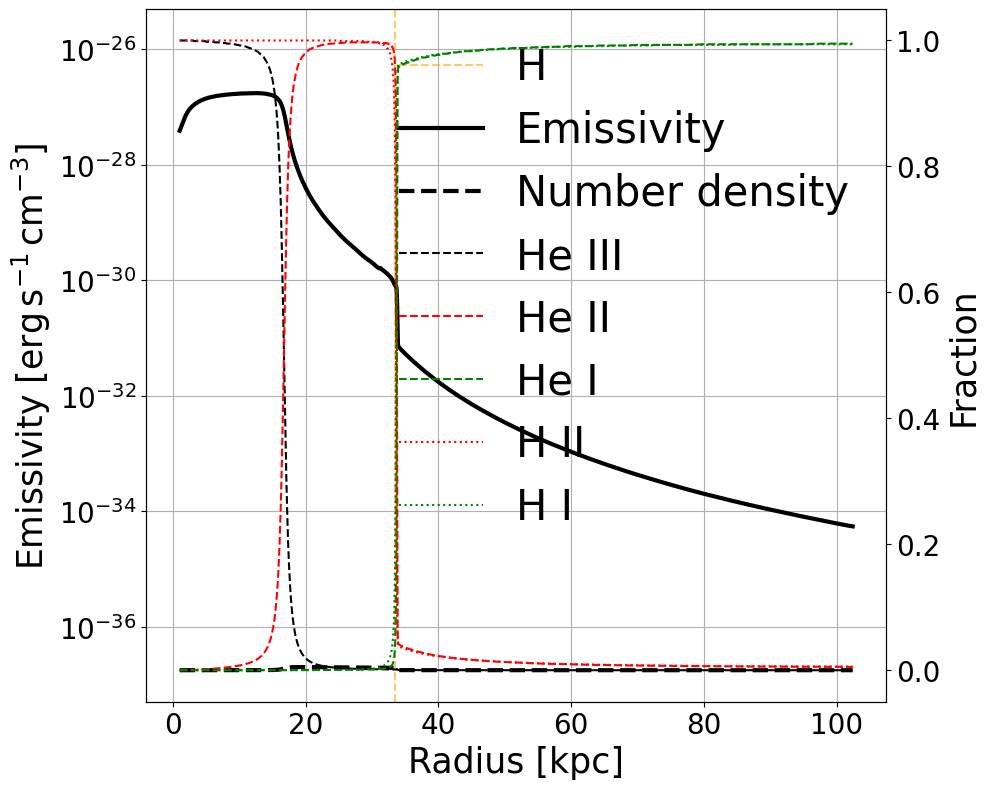

In [36]:
fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(1, 1) 

ax1 = fig.add_subplot(gs[0])


Lum = 44

version = 1
N_H = 22.0
multi = 1
tur = 50.0

print(f'Lum = {Lum}')


CLOUDY_data(Lum, N_H, version, multi)
# === 첫 번째 subplot ===
ax1a = ax1
ax1b = ax1a.twinx()


version = 2
CLOUDY_data(Lum, N_H, version, multi)
# ax1a.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'emis_CIV_{Lum}_{version}'], 'b-',lw=3 ,label=r'Emissivity') # , $\epsilon_{\rm CIV}$

# # ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'frac_CIII_{Lum}_{version}'],'k--',label = 'C III')
# ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'frac_CIV_{Lum}_{version}'],'r--',label = 'C IV')
# ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'frac_CV_{Lum}_{version}'],'g--',label = 'C V')

ax1a.axvline(x=33.5,ymin=0,ymax=1,linestyle='--',color='orange',alpha=0.6,label='H')

ax1a.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'emis_HeII_{Lum}_{version}'], 'k-',lw=3 ,label=r'Emissivity') # , $\epsilon_{\rm CIV}$

ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'nden_HeII_{Lum}_{version}'], 'k--', lw=3, label=r'Number density')

ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'frac_HeIII_{Lum}_{version}'],'k--',label = 'He III')
ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'frac_HeII_{Lum}_{version}'],'r--',label = 'He II')
ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'frac_HeI_{Lum}_{version}'],'g--',label = 'He I')

ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'frac_HII_{Lum}_{version}'],'r:',label = 'H II')
ax1b.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'frac_HI_{Lum}_{version}'],'g:',label = 'H I')




ax1.grid(True)

ax1a.set_xlabel('Radius [kpc]', fontsize=25)
ax1a.set_ylabel(r'Emissivity [$\rm erg \, s^{-1} \,cm^{-3}$]', fontsize=25)
ax1b.set_ylabel(r'Fraction', fontsize=25)

ax1a.set_yscale('log')
# ax1b.set_yscale('log')
ax1a.tick_params(axis='both', labelsize=20)
ax1b.tick_params(axis='y', labelsize=20)
ax1a.set_ylim(5e-38,5e-26)
# ax1b.set_ylim(5e-14,5e-5)
# 범례 통합
lines1, labels1 = ax1a.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=30, frameon=False)

plt.tight_layout()

# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/Emissivity.pdf',bbox_inches="tight")


In [37]:
# Lum = 44

# version = 1
# N_H = 22.0
# multi = 1
# z = 0
# red_shift_f = (1+z)**4
# sr_to_arc = (180*3600 / np.pi)**2
# fac = red_shift_f / sr_to_arc
# vout = 500
# v_emit = 100
# v_rand = 11.8
# vout_make_parameter(z_red_shift,Lum,v_out, v_emit ,v_rand)

# nn = int(vout / 100)
# x = globals()[f'RT_radius_vout_{nn}']
# y =b = photon_number_SB(
#     x,
#     globals()[f'Origin_SB_vout_{nn}'],
#     globals()[f'Lumin_CIV_{Lum}_{version}']
# )[0]

# plt.plot(x,y)

make parameters of v_rand = 50 km/s, v_exp = 100 km/s, v_emit = 100 km/s for CIV
make parameters of v_rand = 50 km/s, v_exp = 500 km/s, v_emit = 100 km/s for CIV
make parameters of v_rand = 50 km/s, v_exp = 1000 km/s, v_emit = 100 km/s for CIV
Make data!!
make parameters of v_rand = 50 km/s, v_exp = 100 km/s, v_emit = 100 km/s for CIV
make parameters of v_rand = 50 km/s, v_exp = 500 km/s, v_emit = 100 km/s for CIV
make parameters of v_rand = 50 km/s, v_exp = 1000 km/s, v_emit = 100 km/s for CIV
Make data!!


Text(3, 1e-13, '$\\nu L_{\\nu} = 10^{45.5}~{\\rm erg \\, s^{-1}}$')

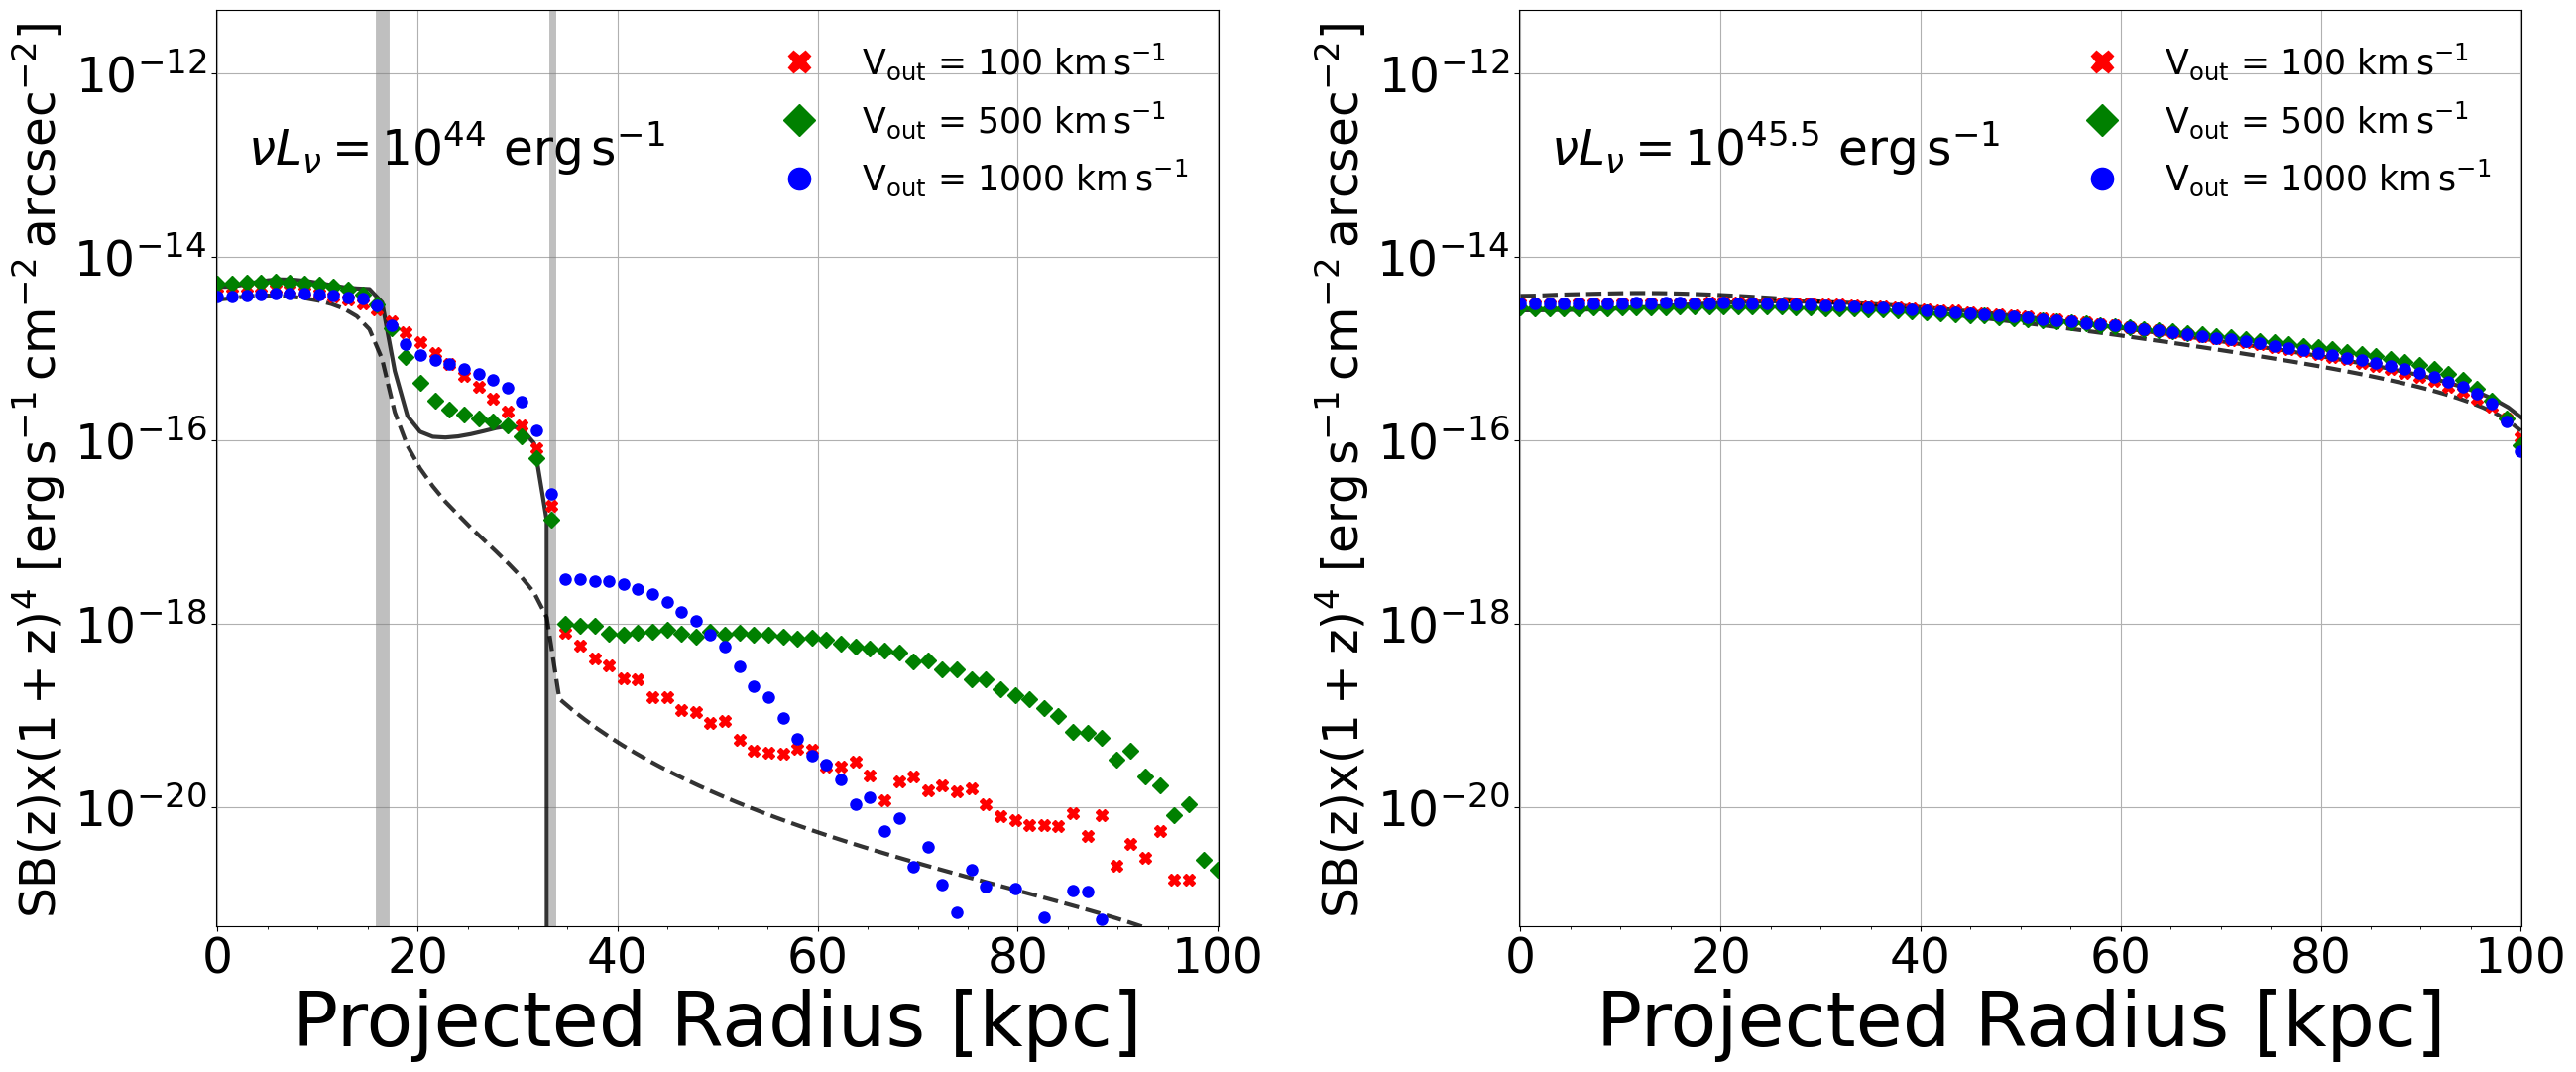

In [38]:

import matplotlib.gridspec as gridspec

import matplotlib.lines as mlines

fig = plt.figure(figsize=(30, 12))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1],wspace=0.3)  #  , width_ratios=[1, 1],  wspace=0.55 

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])


Lum = 44

version = 1
N_H = 22.0
multi = 1
tur = 50.0


# === 첫 번째 subplot ===
z = 0
red_shift_f = (1+z)**4
sr_to_arc = (180*3600 / np.pi)**2
fac = red_shift_f / sr_to_arc


ax1.axvline(x=33.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.5,lw=5)
ax1.axvline(x=16.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.5,lw=10)


# CLOUDY 데이터 플롯 (레이블 숨김)
version = 2
CLOUDY_data(Lum, N_H, version, multi)
heii_line = ax1.plot(
    globals()[f'radius_p_{Lum}_{version}'], 
    globals()[f'SB_HeII_{Lum}_{version}'] * fac, 
    '--',color='k',alpha=0.8,lw=3, label='_nolegend_'
)[0]

version = 2
CLOUDY_data(Lum, N_H, version, multi)
civ_line = ax1.plot(
    globals()[f'radius_p_{Lum}_{version}'], 
    globals()[f'SB_CIV_{Lum}_{version}'] * fac, 
    'k-',alpha=0.8,lw=3, label='_nolegend_'
)[0]

# version = 2
# CLOUDY_data(Lum, N_H, version, multi)
# civ_line = ax1.plot(
#     globals()[f'radius_p_{Lum}_{version}'], 
#     globals()[f'SB_Lya_{Lum}_{version}'] * fac, 
#     'k--',alpha=0.8,lw=3, label='_nolegend_'
# )[0]

v_out = np.array([100,500,1000]) 
# v_out = 100
v_emit = 100 
v_rand = 50
# v_rand = np.array([11.8])
z_red_shift = 0


# color = ['k','Teal','brown']
color=['r','g','b']
rt_scat_markers = []


shape= np.array(['X','D','o'])

vout_make_parameter(z_red_shift,Lum,v_out, v_emit ,v_rand)

for ii, rr in enumerate(v_out):
    nn = int(rr / 100)
    x = globals()[f'RT_radius_vout_{nn}']
    y = b = photon_number_SB(
        x,
        globals()[f'Origin_SB_vout_{nn}'],
        globals()[f'Lumin_CIV_{Lum}_{version}']
    )[1] * fac

    # 1. 보간 함수 생성 (kind='cubic' 또는 'quadratic' 등 선택 가능)
    # f_interp = interp1d(x, y, kind='cubic')

    # # 2. 더 촘촘한 x_new 생성
    # x_new = np.linspace(np.min(x), np.max(x), 500)
    # y_new = f_interp(x_new)

    # 3. 보간된 데이터로 plot
    rt_line = ax1.plot(
        x,
        y,
        color=color[ii],
        marker=shape[ii],
        linestyle='', markersize=8, label=f'$\\rm V_{{\\rm out}}$ = {rr} ${{\\rm km \\,s ^{{-1}}}}$'
    )[0]
    rt_scat_markers.append(rt_line)



# 커스텀 레전드 생성
# cloudy_title = mlines.Line2D([], [], color='none', label='w/o scattering')
# rt_scat_title = mlines.Line2D([], [], color='none', label=f'w/ scattering')

# legend_elements = [
#     # cloudy_title,
#     # mlines.Line2D([], [], color='k',linestyle='-', lw=5, label='He II'),
#     # mlines.Line2D([], [], color='k',linestyle='--', lw=5, alpha=0.5, label='C IV'),
#     [
#         mlines.Line2D([], [], color=color[i], linestyle='-',
#                      lw=5, label=f'$\\rm V_{{\\rm out}}$ = {v} ${{\\rm km \\,s ^{{-1}}}}$')
#         for i, v in enumerate(v_out)
#     ]
# ]

# ax1.legend(handles=legend_elements, loc='best', frameon=False,fontsize=15)
legend = ax1.legend(loc='best', frameon=False,fontsize=25,markerscale=2)
# legend = ax1.legend(handles=legend_elements, loc='best', frameon=False, prop={'family': 'monospace'})
# legend.get_texts()[0].set_fontsize(40)  # CLOUDY
# legend.get_texts()[3].set_fontsize(40)  # RT-Scat

# for text in legend.get_texts():
    # text.set_ha('center')

y_min = (b * fac).min() / 5
ax1.set_xlabel('Projected Radius [kpc]', fontsize=55)
ax1.set_xlim(-0.1,100.1)
ax1.set_ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2} \, arcsec^{-2} ]$ ', fontsize=35)
ax1.set_ylim(5e-22,5e-12)
# ax1.text(2.5,y_min, f'$v_{{\\rm out}} = {v_out[0]}~{{\\rm km \\,s ^{{-1}}}}$',fontsize=18,fontweight='bold')




ax1.set_yscale('log')
ax1.tick_params(axis='both', labelsize=35)
ax1.minorticks_on()
ax1.grid(True)
ax1.text(3,1e-13,s=r'$\nu L_{\nu} = 10^{44}~{\rm erg \, s^{-1}}$',fontsize=35,weight='bold')


Lum = 45.5

z = 0
red_shift_f = (1+z)**4
sr_to_arc = (180*3600 / np.pi)**2
fac = red_shift_f / sr_to_arc

# CLOUDY 데이터 플롯 (레이블 숨김)
version = 2
CLOUDY_data(Lum, N_H, version, multi)
heii_line = ax2.plot(
    globals()[f'radius_p_{Lum}_{version}'], 
    globals()[f'SB_HeII_{Lum}_{version}'] * fac, 
    'k--',alpha=0.8,lw=3, label='_nolegend_'
)[0]

version = 2
CLOUDY_data(Lum, N_H, version, multi)
civ_line = ax2.plot(
    globals()[f'radius_p_{Lum}_{version}'], 
    globals()[f'SB_CIV_{Lum}_{version}'] * fac, 
    'k-',alpha=0.8,lw=3, label='_nolegend_'
)[0]

# version = 2
# CLOUDY_data(Lum, N_H, version, multi)
# civ_line = ax2.plot(
#     globals()[f'radius_p_{Lum}_{version}'], 
#     globals()[f'SB_Lya_{Lum}_{version}'] * fac, 
#     'k--',alpha=0.8,lw=3, label='_nolegend_'
# )[0]


v_out = np.array([100,500,1000]) 
# v_out = 100
v_emit = 100 
v_rand = 50
# v_rand = np.array([11.8])
z_red_shift = 0

Lum = 45.5

# color = ['k','Teal','brown']
color=['r','g','b']
rt_scat_markers = []

vout_make_parameter(z_red_shift,Lum,v_out, v_emit ,v_rand)

for ii, rr in enumerate(v_out):
    nn = int(rr / 100)
    x = globals()[f'RT_radius_vout_{nn}']
    y = b = photon_number_SB(
        x,
        globals()[f'Origin_SB_vout_{nn}'],
        globals()[f'Lumin_CIV_{Lum}_{version}']
    )[1] * fac


    rt_line = ax2.plot(
        x,
        y,
        color=color[ii],
        marker=shape[ii],
        linestyle='', markersize=8, label=f'$\\rm V_{{\\rm out}}$ = {rr} ${{\\rm km \\,s ^{{-1}}}}$'
    )[0]
    rt_scat_markers.append(rt_line)


# 커스텀 레전드 생성
# cloudy_title = mlines.Line2D([], [], color='none', label='w/o scattering')
# rt_scat_title = mlines.Line2D([], [], color='none', label=f'w/ scattering')

# legend_elements = [
#     cloudy_title,
#     mlines.Line2D([], [], color='r',linestyle='--',lw=5, label='He II'),
#     mlines.Line2D([], [], color='b', linestyle='--', lw=5, alpha=0.8, label='C IV'),
#     rt_scat_title,
#     *[
#         mlines.Line2D([], [], color=color[i], linestyle='-',
#                     lw=5, label=f'$\\rm V_{{\\rm out}}$ = {v} ${{\\rm km \\,s ^{{-1}}}}$')
#         for i, v in enumerate(v_out)
#     ]
# ]

# ax1.legend(handles=egend_elements, loc='best', frameon=False,fontsize=15)
legend = ax2.legend(loc='best', frameon=False,fontsize=25,markerscale=2)
# legend = ax1.legend(loc='best', frameon=False, prop={'family': 'monospace'})
# legend.get_texts()[0].set_fontsize(20)  # CLOUDY
# legend.get_texts()[3].set_fontsize(20)  # RT-Scat

# for text in legend.get_texts():
#     text.set_ha('center')

ax2.set_xlabel('Projected Radius [kpc]', fontsize=55)
ax2.set_xlim(-0.1,100.1)
ax2.set_ylim(5e-22,5e-12)
ax2.set_ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2} \, arcsec^{-2} ]$ ', fontsize=35)
# ax2.text(2.5,y_min, f'$v_{{\\rm out}} = {v_out[0]}~{{\\rm km \\,s ^{{-1}}}}$',fontsize=18,fontweight='bold') 
ax2.set_yscale('log')
ax2.tick_params(axis='both', labelsize=35)
ax2.minorticks_on()
ax2.grid(True)
ax2.text(3,1e-13,s=r'$\nu L_{\nu} = 10^{45.5}~{\rm erg \, s^{-1}}$',fontsize=35,weight='bold')

# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/RT_Scat_result.pdf',bbox_inches="tight")

make parameters of v_rand = 50 km/s, v_exp = 100 km/s, v_emit = 100 km/s for CIV
make parameters of v_rand = 50 km/s, v_exp = 500 km/s, v_emit = 100 km/s for CIV
make parameters of v_rand = 50 km/s, v_exp = 1000 km/s, v_emit = 100 km/s for CIV
Make data!!


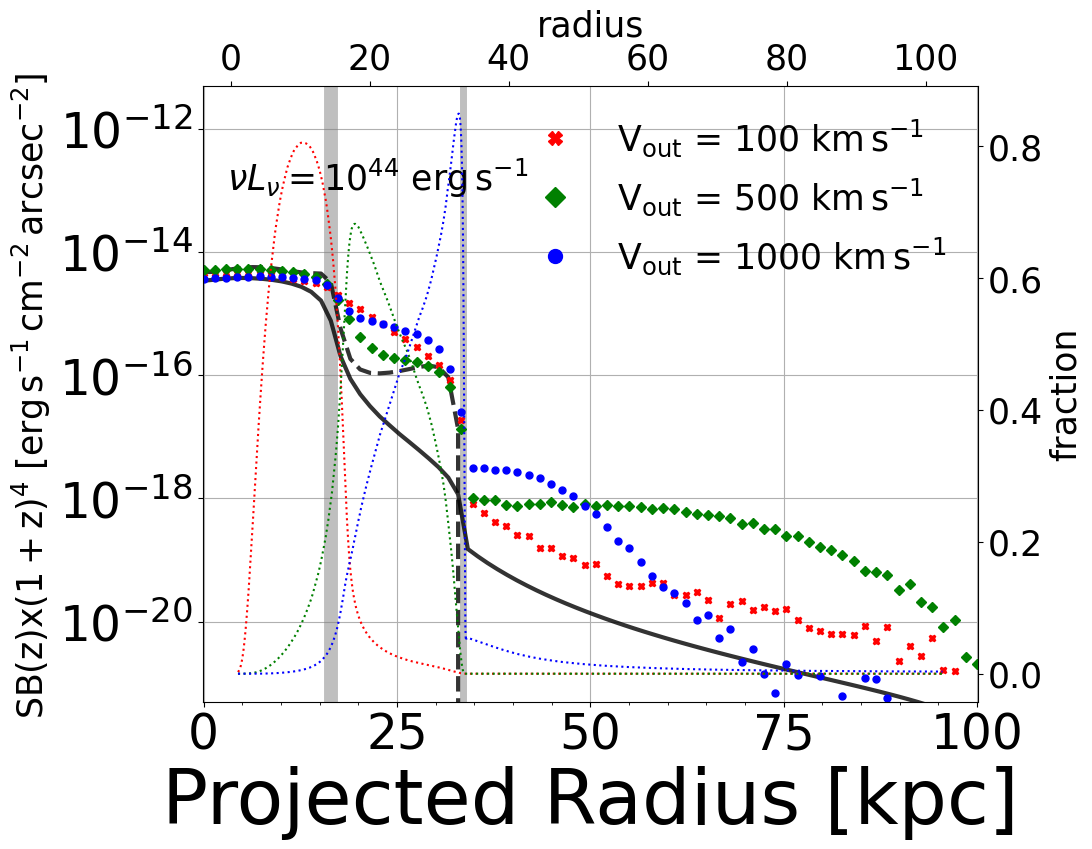

In [39]:

import matplotlib.gridspec as gridspec

import matplotlib.lines as mlines

fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(1, 1)  #  , width_ratios=[1, 1],  wspace=0.55 

ax1 = fig.add_subplot(gs[0])



Lum = 44

version = 1
N_H = 22.0
multi = 1
tur = 50.0


# === 첫 번째 subplot ===
z = 0
red_shift_f = (1+z)**4
sr_to_arc = (180*3600 / np.pi)**2
fac = red_shift_f / sr_to_arc


ax1.axvline(x=33.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.5,lw=5)
ax1.axvline(x=16.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.5,lw=10)


# CLOUDY 데이터 플롯 (레이블 숨김)
version = 2
CLOUDY_data(Lum, N_H, version, multi)
heii_line = ax1.plot(
    globals()[f'radius_p_{Lum}_{version}'], 
    globals()[f'SB_HeII_{Lum}_{version}'] * fac, 
    '-',color='k',alpha=0.8,lw=3, label='_nolegend_'
)[0]

version = 2
CLOUDY_data(Lum, N_H, version, multi)
civ_line = ax1.plot(
    globals()[f'radius_p_{Lum}_{version}'], 
    globals()[f'SB_CIV_{Lum}_{version}'] * fac, 
    'k--',alpha=0.8,lw=3, label='_nolegend_'
)[0]

v_out = np.array([100,500,1000]) 
# v_out = 100
v_emit = 100 
v_rand = 50
# v_rand = np.array([11.8])
z_red_shift = 0


# color = ['k','Teal','brown']
color=['r','g','b']
rt_scat_markers = []


shape= np.array(['X','D','o'])

vout_make_parameter(z_red_shift,Lum,v_out, v_emit ,v_rand)

for ii, rr in enumerate(v_out):
    nn = int(rr / 100)
    x = globals()[f'RT_radius_vout_{nn}']
    y = b = photon_number_SB(
        x,
        globals()[f'Origin_SB_vout_{nn}'],
        globals()[f'Lumin_CIV_{Lum}_{version}']
    )[1] * fac

    # 1. 보간 함수 생성 (kind='cubic' 또는 'quadratic' 등 선택 가능)
    # f_interp = interp1d(x, y, kind='cubic')

    # # 2. 더 촘촘한 x_new 생성
    # x_new = np.linspace(np.min(x), np.max(x), 500)
    # y_new = f_interp(x_new)

    # 3. 보간된 데이터로 plot
    rt_line = ax1.plot(
        x,
        y,
        color=color[ii],
        marker=shape[ii],
        linestyle='', markersize=5, label=f'$\\rm V_{{\\rm out}}$ = {rr} ${{\\rm km \\,s ^{{-1}}}}$'
    )[0]
    rt_scat_markers.append(rt_line)


legend = ax1.legend(loc='best', frameon=False,fontsize=25,markerscale=2)

y_min = (b * fac).min() / 5
ax1.set_xlabel('Projected Radius [kpc]', fontsize=55)
ax1.set_xlim(-0.1,100.1)
ax1.set_ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2} \, arcsec^{-2} ]$ ', fontsize=25)
ax1.set_ylim(5e-22,5e-12)
# ax1.text(2.5,y_min, f'$v_{{\\rm out}} = {v_out[0]}~{{\\rm km \\,s ^{{-1}}}}$',fontsize=18,fontweight='bold')




ax1.set_yscale('log')
ax1.tick_params(axis='both', labelsize=35)
ax1.minorticks_on()
ax1.grid(True)
ax1.text(3,1e-13,s=r'$\nu L_{\nu} = 10^{44}~{\rm erg \, s^{-1}}$',fontsize=25,weight='bold')



ax2 = fig.add_axes(ax1.get_position(), frameon=False)
ax2.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'frac_CV_{Lum}_{version}'],'r:',label = 'C V')
ax2.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'frac_CIV_{Lum}_{version}'],'g:',label = 'C IV')
ax2.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'frac_CIII_{Lum}_{version}'],'b:',label = 'C III')

# ax2.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'frac_HeIII_{Lum}_{version}'],'r--',label = 'C V')
# ax2.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'frac_HeII_{Lum}_{version}'],'g--',label = 'C IV')
# ax2.plot(globals()[f'radius_{Lum}_{version}'], globals()[f'frac_HeI_{Lum}_{version}'],'b--',label = 'C III')

ax2.xaxis.set_ticks_position('top')
ax2.xaxis.set_label_position('top')
ax2.set_xlabel('radius', fontsize=25)

ax2.yaxis.set_ticks_position('right')
ax2.yaxis.set_label_position('right')
ax2.set_ylabel('fraction', fontsize=25)
ax2.tick_params(axis='both', labelsize=25)

make parameters of v_rand = 50 km/s, v_exp = 100 km/s, v_emit = 100 km/s for CIV
make parameters of v_rand = 50 km/s, v_exp = 500 km/s, v_emit = 100 km/s for CIV
make parameters of v_rand = 50 km/s, v_exp = 1000 km/s, v_emit = 100 km/s for CIV
Make data!!
make parameters of v_rand = 50 km/s, v_exp = 100 km/s, v_emit = 100 km/s for CIV
make parameters of v_rand = 50 km/s, v_exp = 500 km/s, v_emit = 100 km/s for CIV
make parameters of v_rand = 50 km/s, v_exp = 1000 km/s, v_emit = 100 km/s for CIV
Make data!!


Text(3, 1e-13, '$\\nu L_{\\nu} = 10^{45.5}~{\\rm erg \\, s^{-1}}$')

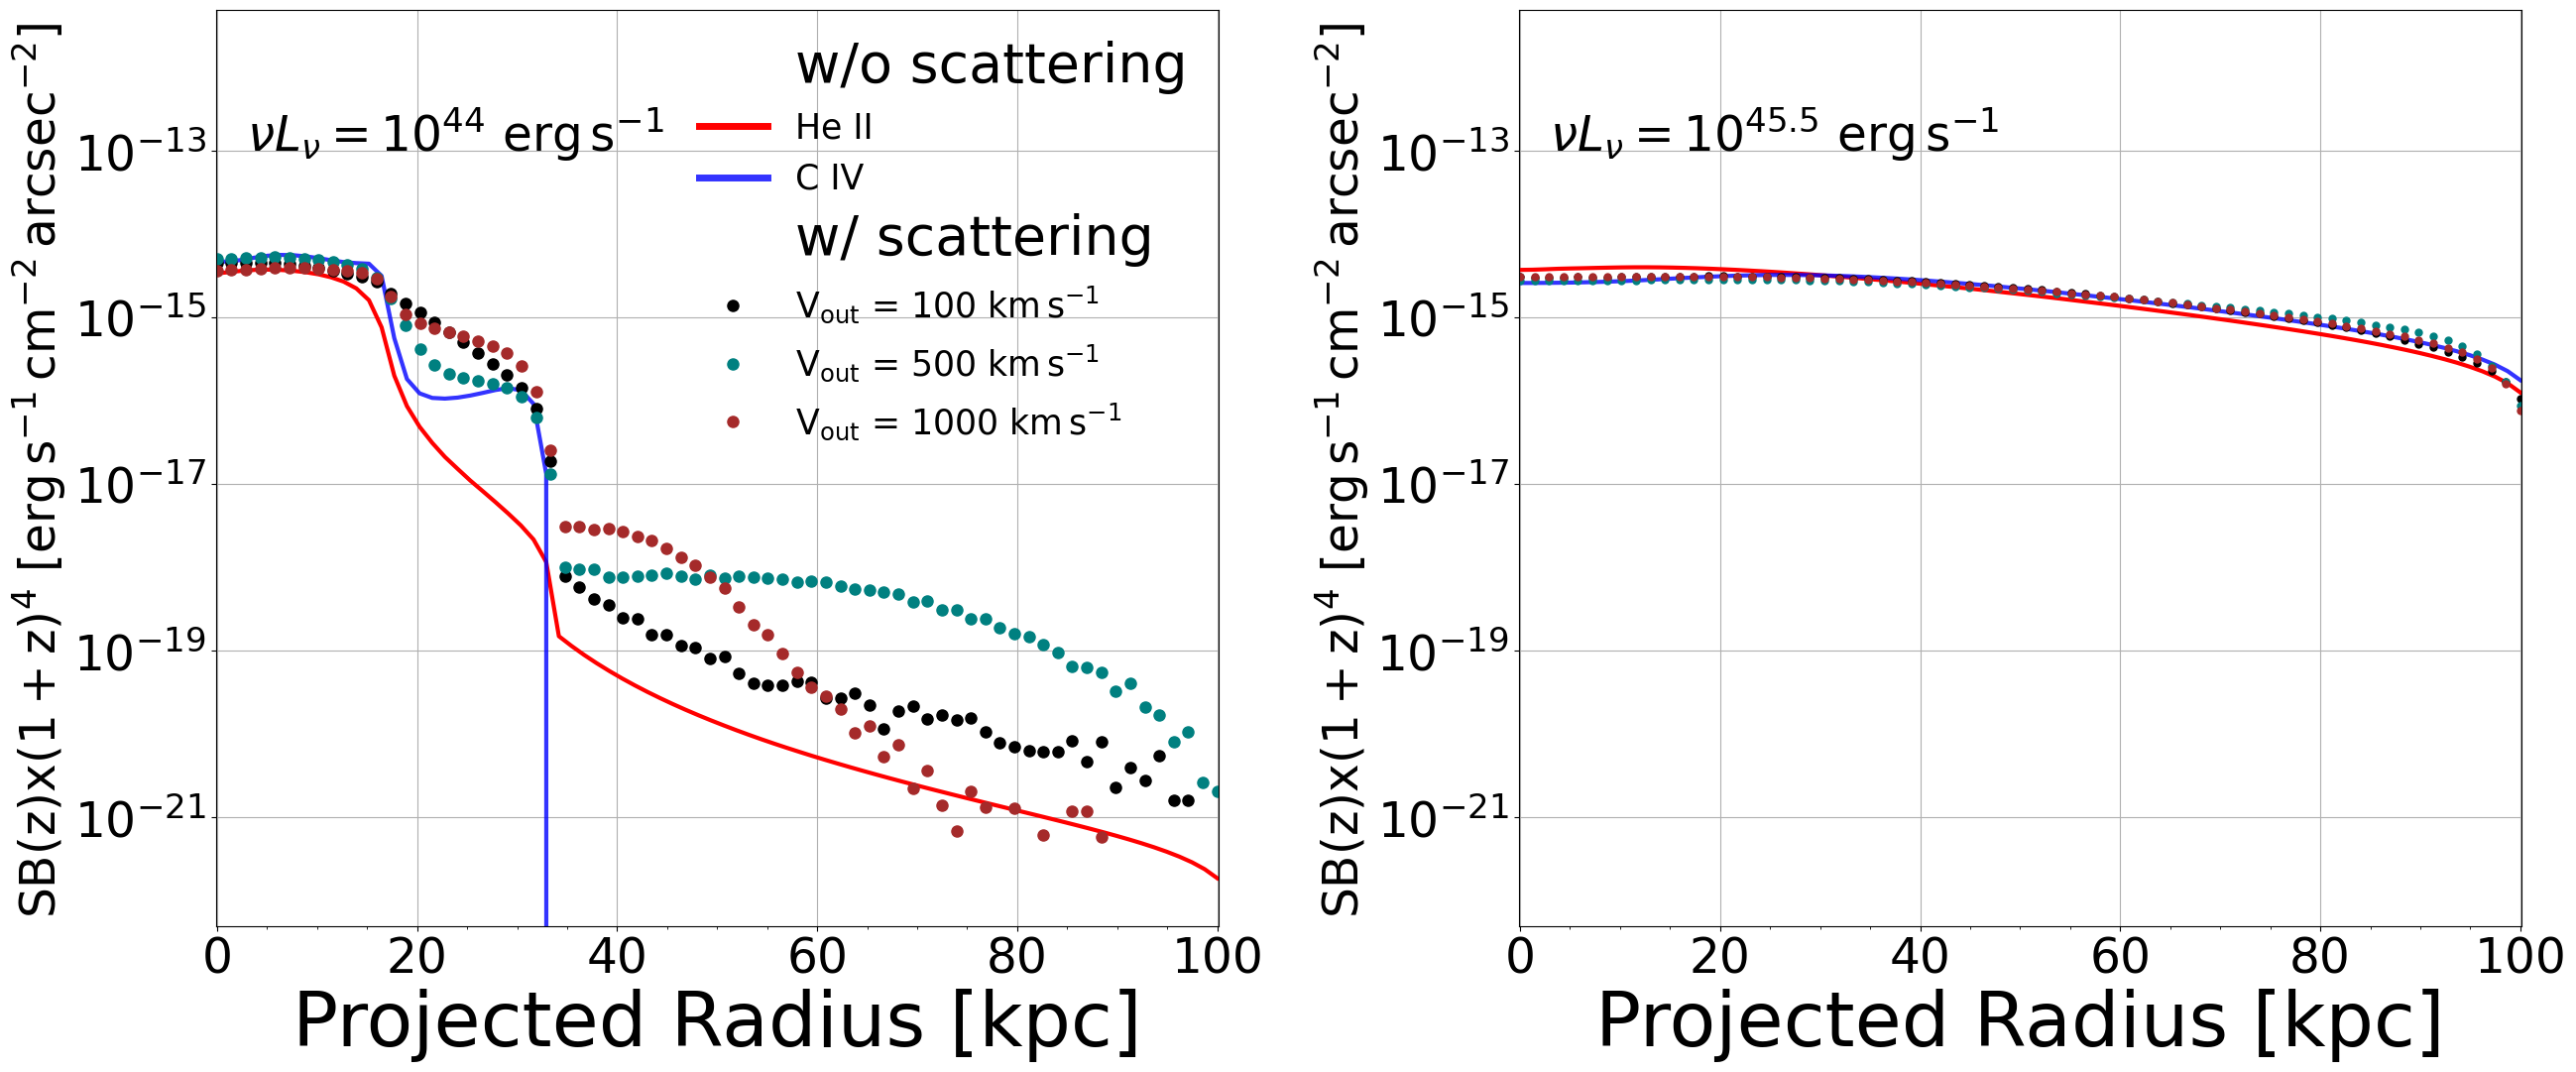

In [40]:

import matplotlib.gridspec as gridspec

import matplotlib.lines as mlines

fig = plt.figure(figsize=(30, 12))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1],wspace=0.3)  #  , width_ratios=[1, 1],  wspace=0.55 

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])


Lum = 44

version = 1
N_H = 22.0
multi = 1
tur = 50.0


# === 첫 번째 subplot ===
z = 0
red_shift_f = (1+z)**4
sr_to_arc = (180*3600 / np.pi)**2
fac = red_shift_f / sr_to_arc

# CLOUDY 데이터 플롯 (레이블 숨김)
version = 2
CLOUDY_data(Lum, N_H, version, multi)
heii_line = ax1.plot(
    globals()[f'radius_p_{Lum}_{version}'], 
    globals()[f'SB_HeII_{Lum}_{version}'] * fac, 
    'r-', lw=3, label='_nolegend_'
)[0]

version = 2
CLOUDY_data(Lum, N_H, version, multi)
civ_line = ax1.plot(
    globals()[f'radius_p_{Lum}_{version}'], 
    globals()[f'SB_CIV_{Lum}_{version}'] * fac, 
    'b-', lw=3, alpha=0.8, label='_nolegend_'
)[0]


rt_scat_markers = []
cloudy_lines = []

# version = 1
# CLOUDY_data(Lum, N_H, version, multi)
# civ_line = ax1.plot(
#     globals()[f'radius_p_{Lum}_{version}'], 
#     globals()[f'SB_CIV_{Lum}_{version}'] * fac, 
#     'b:', lw=3, alpha=0.5, label='CLOUDY'
# )[0]

# cloudy_lines.append(civ_line)



v_out = np.array([100,500,1000]) 
# v_out = 100
v_emit = 100 
v_rand = 50
# v_rand = np.array([11.8])
z_red_shift = 0


color = ['k','Teal','brown']



vout_make_parameter(z_red_shift,Lum,v_out, v_emit ,v_rand)

for ii, rr in enumerate(v_out):
    nn = int(rr/ 100)
    a, b = photon_number_SB(
        globals()[f'RT_radius_vout_{nn}'],
        globals()[f'Origin_SB_vout_{nn}'],
        globals()[f'Lumin_CIV_{Lum}_{version}']
    )
    rt_line = ax1.plot(
        globals()[f'RT_radius_vout_{nn}'], 
        b * fac, 
        color=color[ii],
        marker='o', linestyle='None', markersize=8, label='_nolegend_'
    )[0]
    rt_scat_markers.append(rt_line)





# for ii, rr in enumerate(v_out):
#     nn = int(rr / 100)
#     x = globals()[f'RT_radius_vout_{nn}']
#     y = b = photon_number_SB(
#         x,
#         globals()[f'Origin_SB_vout_{nn}'],
#         globals()[f'Lumin_CIV_{Lum}_{version}']
#     )[1] * fac

#     # 1. 보간 함수 생성 (kind='cubic' 또는 'quadratic' 등 선택 가능)
#     f_interp = interp1d(x, y, kind='cubic')

#     # 2. 더 촘촘한 x_new 생성
#     x_new = np.linspace(np.min(x), np.max(x), 500)
#     y_new = f_interp(x_new)

#     # 3. 보간된 데이터로 plot
#     rt_line = ax1.plot(
#         x_new,
#         y_new,
#         color=color[ii],
#         linestyle='--', lw=5, label='_nolegend_'
#     )[0]
#     rt_scat_markers.append(rt_line)






# 커스텀 레전드 생성

# cloudy_group_handle = mlines.Line2D([], [], 'b:', lw=3, label='CLOUDY')
cloudy_group_handle = mlines.Line2D([], [], color='b', linestyle=':', lw=3,alpha=0.5,label='CLOUDY')

cloudy_title = mlines.Line2D([], [], color='none', label='w/o scattering')
rt_scat_title = mlines.Line2D([], [], color='none', label=f'w/ scattering')

legend_elements = [
    cloudy_title,  # 1. w/o scattering
    mlines.Line2D([], [], color='r', lw=5, label='He II'),  # 2. He II
    mlines.Line2D([], [], color='b', lw=5, alpha=0.8, label='C IV'),  # 3. C IV
    rt_scat_title,  # 4. w/ scattering
    # cloudy_group_handle,  # 5. CLOUDY (여기서 label='CLOUDY')
    *[
        mlines.Line2D([], [], color=color[i], marker='o', linestyle='None', markersize=8, 
                       label=f'$\\rm V_{{\\rm out}}$ = {v} ${{\\rm km \\,s ^{{-1}}}}$')
        for i, v in enumerate(v_out)
    ]  # 6. V_out 마커들
]


# legend_elements = [
#     cloudy_title,  # 1. w/o scattering
#     mlines.Line2D([], [], color='r', lw=5, label='He II'),  # 2. He II
#     mlines.Line2D([], [], color='b', lw=5, alpha=0.8, label='C IV'),  # 3. C IV
#     rt_scat_title,  # 4. w/ scattering
#     cloudy_group_handle,  # 5. CLOUDY (여기서 label='CLOUDY')
#     *[
#         mlines.Line2D([], [], color=color[i], linestyle='--',
#                      lw=5, label=f'$\\rm V_{{\\rm out}}$ = {v} ${{\\rm km \\,s ^{{-1}}}}$')
#         for i, v in enumerate(v_out)
#     ]
# ]





# ax1.legend(handles=legend_elements, loc='best', frameon=False,fontsize=15)
legend = ax1.legend(handles=legend_elements, loc='best', frameon=False,fontsize=25)
# legend = ax1.legend(handles=legend_elements, loc='best', frameon=False, prop={'family': 'monospace'})
legend.get_texts()[0].set_fontsize(40)  # CLOUDY
legend.get_texts()[3].set_fontsize(40)  # RT-Scat

for text in legend.get_texts():
    text.set_ha('center')

y_min = (b * fac).min() / 5
ax1.set_xlabel('Projected Radius [kpc]', fontsize=55)
ax1.set_xlim(-0.1,100.1)
ax1.set_ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2} \, arcsec^{-2} ]$ ', fontsize=35)
ax1.set_ylim(5e-23,5e-12)
# ax1.text(2.5,y_min, f'$v_{{\\rm out}} = {v_out[0]}~{{\\rm km \\,s ^{{-1}}}}$',fontsize=18,fontweight='bold')


ax1.set_yscale('log')
ax1.tick_params(axis='both', labelsize=35)
ax1.minorticks_on()
ax1.grid(True)
ax1.text(3,1e-13,s=r'$\nu L_{\nu} = 10^{44}~{\rm erg \, s^{-1}}$',fontsize=35,weight='bold')


Lum = 45.5

z = 0
red_shift_f = (1+z)**4
sr_to_arc = (180*3600 / np.pi)**2
fac = red_shift_f / sr_to_arc

# CLOUDY 데이터 플롯 (레이블 숨김)
version = 2
CLOUDY_data(Lum, N_H, version, multi)
heii_line = ax2.plot(
    globals()[f'radius_p_{Lum}_{version}'], 
    globals()[f'SB_HeII_{Lum}_{version}'] * fac, 
    'r-', lw=3, label='_nolegend_'
)[0]

version = 2
CLOUDY_data(Lum, N_H, version, multi)
civ_line = ax2.plot(
    globals()[f'radius_p_{Lum}_{version}'], 
    globals()[f'SB_CIV_{Lum}_{version}'] * fac, 
    'b-', lw=3, alpha=0.8, label='_nolegend_'
)[0]

rt_scat_markers = []


# version = 1
# CLOUDY_data(Lum, N_H, version, multi)
# civ_line = ax2.plot(
#     globals()[f'radius_p_{Lum}_{version}'], 
#     globals()[f'SB_CIV_{Lum}_{version}'] * fac, 
#     'b:', lw=3, alpha=0.5, label='CLOUDY'
# )[0]


v_out = np.array([100,500,1000]) 
# v_out = 100
v_emit = 100 
v_rand = 50
# v_rand = np.array([11.8])
z_red_shift = 0


color = ['k','Teal','brown']


vout_make_parameter(z_red_shift,Lum,v_out, v_emit ,v_rand)

for ii, rr in enumerate(v_out):
    nn = int(rr/ 100)   
    a, b = photon_number_SB(
        globals()[f'RT_radius_vout_{nn}'],
        globals()[f'Origin_SB_vout_{nn}'],
        globals()[f'Lumin_CIV_{Lum}_{version}']
    )
    rt_line = ax2.plot(
        globals()[f'RT_radius_vout_{nn}'], 
        b * fac, 
        color=color[ii], 
        marker='o', linestyle='None', markersize=5, label='_nolegend_'
    )[0]
    rt_scat_markers.append(rt_line)

# 커스텀 레전드 생성
cloudy_title = mlines.Line2D([], [], color='none', label='w/o scattering')
rt_scat_title = mlines.Line2D([], [], color='none', label=f'w/ scattering')

legend_elements = [
    cloudy_title,
    mlines.Line2D([], [], color='r', lw=5, label='He II'),
    mlines.Line2D([], [], color='b', lw=5, alpha=0.8, label='C IV'),
    rt_scat_title,
    *[
        mlines.Line2D([], [], color=color[i], marker='o', linestyle='None', markersize=5,
                       label=f'$\\rm V_{{\\rm out}}$ = {v} ${{\\rm km \\,s ^{{-1}}}}$')
        for i, v in enumerate(v_out)
    ]
]

# ax1.legend(handles=legend_elements, loc='best', frameon=False,fontsize=15)
# legend = ax2.legend(handles=legend_elements, loc='upper right', frameon=False,fontsize=15)
# # legend = ax1.legend(handles=legend_elements, loc='best', frameon=False, prop={'family': 'monospace'})
# legend.get_texts()[0].set_fontsize(20)  # CLOUDY
# legend.get_texts()[3].set_fontsize(20)  # RT-Scat

for text in legend.get_texts():
    text.set_ha('center')

ax2.set_xlabel('Projected Radius [kpc]', fontsize=55)
ax2.set_xlim(-0.1,100.1)
ax2.set_ylim(5e-23,5e-12)
ax2.set_ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2} \, arcsec^{-2} ]$ ', fontsize=35)
# ax2.text(2.5,y_min, f'$v_{{\\rm out}} = {v_out[0]}~{{\\rm km \\,s ^{{-1}}}}$',fontsize=18,fontweight='bold') 
ax2.set_yscale('log')
ax2.tick_params(axis='both', labelsize=35)
ax2.minorticks_on()
ax2.grid(True)
ax2.text(3,1e-13,s=r'$\nu L_{\nu} = 10^{45.5}~{\rm erg \, s^{-1}}$',fontsize=35,weight='bold')

# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/RT_Scat_result.pdf',bbox_inches="tight")
# Line2D.__init__() takes 3 positional arguments but 4 were given

In [41]:

# import matplotlib.gridspec as gridspec

# import matplotlib.lines as mlines

# fig = plt.figure(figsize=(30, 15))
# gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1],wspace=0.3)  #  , width_ratios=[1, 1],  wspace=0.55 

# ax1 = fig.add_subplot(gs[0])
# ax2 = fig.add_subplot(gs[1])


# Lum = 44

# version = 1
# N_H = 22.0
# multi = 1
# tur = 50.0


# # === 첫 번째 subplot ===
# z = 0
# red_shift_f = (1+z)**4
# sr_to_arc = (180*3600 / np.pi)**2
# fac = red_shift_f / sr_to_arc

# # CLOUDY 데이터 플롯 (레이블 숨김)
# version = 2
# CLOUDY_data(Lum, N_H, version, multi)
# heii_line = ax1.plot(
#     globals()[f'radius_p_{Lum}_{version}'], 
#     globals()[f'SB_HeII_{Lum}_{version}'] * fac, 
#     'r--', lw=3, label='_nolegend_'
# )[0]

# version = 2
# CLOUDY_data(Lum, N_H, version, multi)
# civ_line = ax1.plot(
#     globals()[f'radius_p_{Lum}_{version}'], 
#     globals()[f'SB_CIV_{Lum}_{version}'] * fac, 
#     'b--', lw=3, alpha=0.8, label='_nolegend_'
# )[0]


# rt_scat_markers = []
# cloudy_lines = []

# version = 1
# CLOUDY_data(Lum, N_H, version, multi)
# civ_line = ax1.plot(
#     globals()[f'radius_p_{Lum}_{version}'], 
#     globals()[f'SB_CIV_{Lum}_{version}'] * fac, 
#     'b:', lw=3, alpha=0.5, label='CLOUDY'
# )[0]

# cloudy_lines.append(civ_line)



# v_out = np.array([100,500,1000]) 
# # v_out = 100
# v_emit = 100 
# v_rand = 50
# # v_rand = np.array([11.8])
# z_red_shift = 0


# color = ['k','Teal','brown']



# vout_make_parameter(z_red_shift,Lum,v_out, v_emit ,v_rand)

# # for ii, rr in enumerate(v_out):
# #     nn = int(rr/ 100)
# #     a, b = photon_number_SB(
# #         globals()[f'RT_radius_vout_{nn}'],
# #         globals()[f'Origin_SB_vout_{nn}'],
# #         globals()[f'Lumin_CIV_{Lum}_{version}']
# #     )
# #     rt_line = ax1.plot(
# #         globals()[f'RT_radius_vout_{nn}'], 
# #         b * fac, 
# #         color=color[ii],
# #         marker='o', linestyle='None', markersize=8, label='_nolegend_'
# #     )[0]
# #     rt_scat_markers.append(rt_line)





# for ii, rr in enumerate(v_out):
#     nn = int(rr / 100)
#     x = globals()[f'RT_radius_vout_{nn}']
#     y = b = photon_number_SB(
#         x,
#         globals()[f'Origin_SB_vout_{nn}'],
#         globals()[f'Lumin_CIV_{Lum}_{version}']
#     )[1] * fac

#     # 1. 보간 함수 생성 (kind='cubic' 또는 'quadratic' 등 선택 가능)
#     f_interp = interp1d(x, y, kind='cubic')

#     # 2. 더 촘촘한 x_new 생성
#     x_new = np.linspace(np.min(x), np.max(x), 500)
#     y_new = f_interp(x_new)

#     # 3. 보간된 데이터로 plot
#     rt_line = ax1.plot(
#         x_new,
#         y_new,
#         color=color[ii],
#         linestyle='-', lw=5, label='_nolegend_'
#     )[0]
#     rt_scat_markers.append(rt_line)






# # 커스텀 레전드 생성

# # cloudy_group_handle = mlines.Line2D([], [], 'b:', lw=3, label='CLOUDY')
# cloudy_group_handle = mlines.Line2D([], [], color='b', linestyle=':', lw=3,alpha=0.5,label='CLOUDY')

# cloudy_title = mlines.Line2D([], [], color='none', label='w/o scattering')
# rt_scat_title = mlines.Line2D([], [], color='none', label=f'w/ scattering')

# # legend_elements = [
# #     cloudy_title,  # 1. w/o scattering
# #     mlines.Line2D([], [], color='r', lw=5, label='He II'),  # 2. He II
# #     mlines.Line2D([], [], color='b', lw=5, alpha=0.8, label='C IV'),  # 3. C IV
# #     rt_scat_title,  # 4. w/ scattering
# #     cloudy_group_handle,  # 5. CLOUDY (여기서 label='CLOUDY')
# #     *[
# #         mlines.Line2D([], [], color=color[i], marker='o', linestyle='None', markersize=8, 
# #                        label=f'$\\rm V_{{\\rm out}}$ = {v} ${{\\rm km \\,s ^{{-1}}}}$')
# #         for i, v in enumerate(v_out)
# #     ]  # 6. V_out 마커들
# # ]


# legend_elements = [
#     cloudy_title,  # 1. w/o scattering
#     mlines.Line2D([], [], color='r', lw=5, linestyle='--',label='He II'),  # 2. He II
#     mlines.Line2D([], [], color='b', linestyle='--',lw=5, alpha=0.8, label='C IV'),  # 3. C IV
#     rt_scat_title,  # 4. w/ scattering
#     cloudy_group_handle,  # 5. CLOUDY (여기서 label='CLOUDY')
#     *[
#         mlines.Line2D([], [], color=color[i], linestyle='-',
#                      lw=5, label=f'$\\rm V_{{\\rm out}}$ = {v} ${{\\rm km \\,s ^{{-1}}}}$')
#         for i, v in enumerate(v_out)
#     ]
# ]





# # ax1.legend(handles=legend_elements, loc='best', frameon=False,fontsize=15)
# legend = ax1.legend(handles=legend_elements, loc='best', frameon=False,fontsize=25)
# # legend = ax1.legend(handles=legend_elements, loc='best', frameon=False, prop={'family': 'monospace'})
# legend.get_texts()[0].set_fontsize(40)  # CLOUDY
# legend.get_texts()[3].set_fontsize(40)  # RT-Scat

# for text in legend.get_texts():
#     text.set_ha('center')

# y_min = (b * fac).min() / 5
# ax1.set_xlabel('Projected Radius [kpc]', fontsize=55)
# ax1.set_xlim(-0.1,100.1)
# ax1.set_ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2} \, arcsec^{-2} ]$ ', fontsize=35)
# ax1.set_ylim(5e-25,5e-12)
# # ax1.text(2.5,y_min, f'$v_{{\\rm out}} = {v_out[0]}~{{\\rm km \\,s ^{{-1}}}}$',fontsize=18,fontweight='bold')


# ax1.set_yscale('log')
# ax1.tick_params(axis='both', labelsize=35)
# ax1.minorticks_on()
# ax1.grid(True)
# ax1.text(3,1e-13,s=r'$\nu L_{\nu} = 10^{44}~{\rm erg \, s^{-1}}$',fontsize=35,weight='bold')


# Lum = 45.5

# z = 0
# red_shift_f = (1+z)**4
# sr_to_arc = (180*3600 / np.pi)**2
# fac = red_shift_f / sr_to_arc

# # CLOUDY 데이터 플롯 (레이블 숨김)
# version = 2
# CLOUDY_data(Lum, N_H, version, multi)
# heii_line = ax2.plot(
#     globals()[f'radius_p_{Lum}_{version}'], 
#     globals()[f'SB_HeII_{Lum}_{version}'] * fac, 
#     'r--', lw=3, label='_nolegend_'
# )[0]

# version = 2
# CLOUDY_data(Lum, N_H, version, multi)
# civ_line = ax2.plot(
#     globals()[f'radius_p_{Lum}_{version}'], 
#     globals()[f'SB_CIV_{Lum}_{version}'] * fac, 
#     'b--', lw=3, alpha=0.8, label='_nolegend_'
# )[0]

# rt_scat_markers = []


# version = 1
# CLOUDY_data(Lum, N_H, version, multi)
# civ_line = ax2.plot(
#     globals()[f'radius_p_{Lum}_{version}'], 
#     globals()[f'SB_CIV_{Lum}_{version}'] * fac, 
#     'b:', lw=3, alpha=0.5, label='CLOUDY'
# )[0]


# v_out = np.array([100,500,1000]) 
# # v_out = 100
# v_emit = 100 
# v_rand = 50
# # v_rand = np.array([11.8])
# z_red_shift = 0


# color = ['k','Teal','brown']


# vout_make_parameter(z_red_shift,Lum,v_out, v_emit ,v_rand)

# for ii, rr in enumerate(v_out):
#     nn = int(rr / 100)
#     x = globals()[f'RT_radius_vout_{nn}']
#     y = b = photon_number_SB(
#         x,
#         globals()[f'Origin_SB_vout_{nn}'],
#         globals()[f'Lumin_CIV_{Lum}_{version}']
#     )[1] * fac

#     # 1. 보간 함수 생성 (kind='cubic' 또는 'quadratic' 등 선택 가능)
#     f_interp = interp1d(x, y, kind='cubic')

#     # 2. 더 촘촘한 x_new 생성
#     x_new = np.linspace(np.min(x), np.max(x), 500)
#     y_new = f_interp(x_new)

#     # 3. 보간된 데이터로 plot
#     rt_line = ax2.plot(
#         x_new,
#         y_new,
#         color=color[ii],
#         linestyle='-', lw=5, label='_nolegend_'
#     )[0]
#     rt_scat_markers.append(rt_line)




# # 커스텀 레전드 생성
# cloudy_title = mlines.Line2D([], [], color='none', label='w/o scattering')
# rt_scat_title = mlines.Line2D([], [], color='none', label=f'w/ scattering')

# legend_elements = [
#     cloudy_title,  # 1. w/o scattering
#     mlines.Line2D([], [], color='r', lw=5, linestyle='--',label='He II'),  # 2. He II
#     mlines.Line2D([], [], color='b', linestyle='--',lw=5, alpha=0.8, label='C IV'),  # 3. C IV
#     rt_scat_title,  # 4. w/ scattering
#     cloudy_group_handle,  # 5. CLOUDY (여기서 label='CLOUDY')
#     *[
#         mlines.Line2D([], [], color=color[i], linestyle='-',
#                      lw=5, label=f'$\\rm V_{{\\rm out}}$ = {v} ${{\\rm km \\,s ^{{-1}}}}$')
#         for i, v in enumerate(v_out)
#     ]
# ]

# # ax1.legend(handles=legend_elements, loc='best', frameon=False,fontsize=15)
# # legend = ax2.legend(handles=legend_elements, loc='upper right', frameon=False,fontsize=15)
# # # legend = ax1.legend(handles=legend_elements, loc='best', frameon=False, prop={'family': 'monospace'})
# # legend.get_texts()[0].set_fontsize(20)  # CLOUDY
# # legend.get_texts()[3].set_fontsize(20)  # RT-Scat

# for text in legend.get_texts():
#     text.set_ha('center')

# ax2.set_xlabel('Projected Radius [kpc]', fontsize=55)
# ax2.set_xlim(-0.1,100.1)
# ax2.set_ylim(5e-25,5e-12)
# ax2.set_ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2} \, arcsec^{-2} ]$ ', fontsize=35)
# # ax2.text(2.5,y_min, f'$v_{{\\rm out}} = {v_out[0]}~{{\\rm km \\,s ^{{-1}}}}$',fontsize=18,fontweight='bold') 
# ax2.set_yscale('log')
# ax2.tick_params(axis='both', labelsize=35)
# ax2.minorticks_on()
# ax2.grid(True)
# ax2.text(3,1e-13,s=r'$\nu L_{\nu} = 10^{45.5}~{\rm erg \, s^{-1}}$',fontsize=35,weight='bold')

# # plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/RT_Scat_result_appendix.pdf',bbox_inches="tight")
# # Line2D.__init__() takes 3 positional arguments but 4 were given

In [42]:

# import matplotlib.gridspec as gridspec

# import matplotlib.lines as mlines

# fig = plt.figure(figsize=(30, 12))
# gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1],wspace=0.3)  #  , width_ratios=[1, 1],  wspace=0.55 

# ax1 = fig.add_subplot(gs[0])
# ax2 = fig.add_subplot(gs[1])


# Lum = 44

# version = 1
# N_H = 22.0
# multi = 1
# tur = 50.0


# # === 첫 번째 subplot ===
# z = 0
# red_shift_f = (1+z)**4
# sr_to_arc = (180*3600 / np.pi)**2
# fac = red_shift_f / sr_to_arc

# # CLOUDY 데이터 플롯 (레이블 숨김)
# version = 2 
# CLOUDY_data(Lum, N_H, version, multi)
# heii_line = ax1.plot(
#     globals()[f'radius_p_{Lum}_{version}'], 
#     globals()[f'SB_HeII_{Lum}_{version}'] * fac, 
#     'r--', lw=3, label='_nolegend_'
# )[0]

# version = 2
# CLOUDY_data(Lum, N_H, version, multi)
# civ_line = ax1.plot(
#     globals()[f'radius_p_{Lum}_{version}'], 
#     globals()[f'SB_CIV_{Lum}_{version}'] * fac, 
#     'b--', lw=3, alpha=0.8, label='_nolegend_'
# )[0]

# v_out = np.array([100]) 
# # v_out = 100
# v_emit = 100 
# v_rand = np.array([11.8,50,100]) 
# # v_rand = np.array([11.8])
# z_red_shift = 0


# color = ['k','Teal','brown']
# rt_scat_markers = []
# for ii, rr in enumerate(v_rand):
#     nn = int(v_out[0]/ 100)
#     vout_make_parameter(z_red_shift,Lum,v_out, v_emit ,rr)
#     a, b = photon_number_SB(
#         globals()[f'RT_radius_vout_{nn}'],
#         globals()[f'Origin_SB_vout_{nn}'],
#         globals()[f'Lumin_CIV_{Lum}_{version}']
#     )
#     rt_line = ax1.plot(
#         globals()[f'RT_radius_vout_{nn}'], 
#         b * fac, 
#         color=color[ii], 
#         linestyle='-', lw=5,label='_nolegend_'
#     )[0]
#     rt_scat_markers.append(rt_line)

# # 커스텀 레전드 생성
# cloudy_title = mlines.Line2D([], [], color='none', label='w/o scattering')
# rt_scat_title = mlines.Line2D([], [], color='none', label=f'w/ scattering')

# legend_elements = [
#     cloudy_title,
#     mlines.Line2D([], [], color='r', linestyle='--',lw=5, label='He II'),
#     mlines.Line2D([], [], color='b',linestyle='--', lw=5, alpha=0.8, label='C IV'),
#     rt_scat_title,
#     *[
#         mlines.Line2D([], [], color=color[i], linestyle='-',
#                      lw=5, label=f'$\sigma_{{\\rm R}}$ = {v} ${{\\rm km \\,s ^{{-1}}}}$')
#         for i, v in enumerate(v_rand)
#     ]
# ]


# # ax1.legend(handles=legend_elements, loc='best', frameon=False,fontsize=15)
# legend = ax1.legend(handles=legend_elements, loc='best', frameon=False,fontsize=25)
# # legend = ax1.legend(handles=legend_elements, loc='best', frameon=False, prop={'family': 'monospace'})
# legend.get_texts()[0].set_fontsize(40)  # CLOUDY
# legend.get_texts()[3].set_fontsize(40)  # RT-Scat

# for text in legend.get_texts():
#     text.set_ha('center')

# y_min = (b * fac).min() / 5
# ax1.set_xlabel('Projected Radius [kpc]', fontsize=55)
# ax1.set_xlim(-0.1,100.1)
# ax1.set_ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2} \, arcsec^{-2} ]$ ', fontsize=35)
# ax1.set_ylim(5e-22,5e-12)
# # ax1.text(2.5,y_min, f'$v_{{\\rm out}} = {v_out[0]}~{{\\rm km \\,s ^{{-1}}}}$',fontsize=18,fontweight='bold')


# ax1.set_yscale('log')
# ax1.tick_params(axis='both', labelsize=35)
# ax1.minorticks_on()
# ax1.grid(True)
# ax1.text(3,1e-13,s=r'$\nu L_{\nu} = 10^{44}~{\rm erg \, s^{-1}}$',fontsize=35,weight='bold')


# Lum = 45.5

# z = 0
# red_shift_f = (1+z)**4
# sr_to_arc = (180*3600 / np.pi)**2
# fac = red_shift_f / sr_to_arc

# # CLOUDY 데이터 플롯 (레이블 숨김)
# version = 2 
# CLOUDY_data(Lum, N_H, version, multi)
# heii_line = ax2.plot(
#     globals()[f'radius_p_{Lum}_{version}'], 
#     globals()[f'SB_HeII_{Lum}_{version}'] * fac, 
#     'r--', lw=3, label='_nolegend_'
# )[0]

# version = 2
# CLOUDY_data(Lum, N_H, version, multi)
# civ_line = ax2.plot(
#     globals()[f'radius_p_{Lum}_{version}'], 
#     globals()[f'SB_CIV_{Lum}_{version}'] * fac, 
#     'b--', lw=3, alpha=0.8, label='_nolegend_'
# )[0]

# v_out = np.array([500]) 
# # v_out = 100
# v_emit = 100 
# v_rand = np.array([11.8,50,100])
# # v_rand = np.array([11.8])
# z_red_shift = 0


# color = ['k','Teal','brown']
# rt_scat_markers = []
# for ii, rr in enumerate(v_rand):
#     nn = int(v_out[0]/ 100)
#     vout_make_parameter(z_red_shift,Lum,v_out, v_emit ,rr)
#     a, b = photon_number_SB(
#         globals()[f'RT_radius_vout_{nn}'],
#         globals()[f'Origin_SB_vout_{nn}'],
#         globals()[f'Lumin_CIV_{Lum}_{version}']
#     )
#     rt_line = ax2.plot(
#         globals()[f'RT_radius_vout_{nn}'], 
#         b * fac, 
#         color=color[ii], 
#         linestyle='-', lw=5,label='_nolegend_'
#     )[0]
#     rt_scat_markers.append(rt_line)

# # 커스텀 레전드 생성
# cloudy_title = mlines.Line2D([], [], color='none', label='w/o scattering')
# rt_scat_title = mlines.Line2D([], [], color='none', label=f'w/ scattering')

# legend_elements = [
#     cloudy_title,
#     mlines.Line2D([], [], color='r',linestyle='--', lw=5, label='He II'),
#     mlines.Line2D([], [], color='b',linestyle='--', lw=5, alpha=0.8, label='C IV'),
#     rt_scat_title,
#     *[
#         mlines.Line2D([], [], color=color[i], linestyle='-',
#                      lw=5, label=f'$\sigma_{{\\rm R}}$ = {v} ${{\\rm km \\,s ^{{-1}}}}$')
#         for i, v in enumerate(v_rand)
#     ]
# ]


# # ax1.legend(handles=legend_elements, loc='best', frameon=False,fontsize=15)
# # legend = ax2.legend(handles=legend_elements, loc='upper right', frameon=False,fontsize=15)
# # # legend = ax1.legend(handles=legend_elements, loc='best', frameon=False, prop={'family': 'monospace'})
# # legend.get_texts()[0].set_fontsize(20)  # CLOUDY
# # legend.get_texts()[3].set_fontsize(20)  # RT-Scat

# for text in legend.get_texts():
#     text.set_ha('center')

# ax2.set_xlabel('Projected Radius [kpc]', fontsize=55)
# ax2.set_xlim(-0.1,100.1)
# ax2.set_ylim(5e-22,5e-12)
# ax2.set_ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2} \, arcsec^{-2} ]$ ', fontsize=35)
# # ax2.text(2.5,y_min, f'$v_{{\\rm out}} = {v_out[0]}~{{\\rm km \\,s ^{{-1}}}}$',fontsize=18,fontweight='bold') 
# ax2.set_yscale('log')
# ax2.tick_params(axis='both', labelsize=35)
# ax2.minorticks_on()
# ax2.grid(True)
# ax2.text(3,1e-13,s=r'$\nu L_{\nu} = 10^{45.5}~{\rm erg \, s^{-1}}$',fontsize=35,weight='bold')



# # plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/RT_Scat_result_Random.pdf',bbox_inches="tight")

In [43]:

# import matplotlib.gridspec as gridspec

# import matplotlib.lines as mlines

# fig = plt.figure(figsize=(30, 12))
# gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1],wspace=0.3)  #  , width_ratios=[1, 1],  wspace=0.55 

# ax1 = fig.add_subplot(gs[0])
# ax2 = fig.add_subplot(gs[1])


# Lum = 44

# version = 1
# N_H = 22.0
# multi = 1
# tur = 50.0


# # === 첫 번째 subplot ===
# z = 0
# red_shift_f = (1+z)**4
# sr_to_arc = (180*3600 / np.pi)**2
# fac = red_shift_f / sr_to_arc

# # CLOUDY 데이터 플롯 (레이블 숨김)
# version = 1 
# CLOUDY_data(Lum, N_H, version, multi)
# heii_line = ax1.plot(
#     globals()[f'radius_p_{Lum}_{version}'], 
#     globals()[f'SB_HeII_{Lum}_{version}'] * fac, 
#     'r-', lw=3, label='_nolegend_'
# )[0]

# version = 2
# CLOUDY_data(Lum, N_H, version, multi)
# civ_line = ax1.plot(
#     globals()[f'radius_p_{Lum}_{version}'], 
#     globals()[f'SB_CIV_{Lum}_{version}'] * fac, 
#     'b-', lw=3, alpha=0.8, label='_nolegend_'
# )[0]

# v_out = np.array([100]) 
# # v_out = 100
# v_emit = 100 
# v_rand = np.array([11.8,50,100]) 
# # v_rand = np.array([11.8])
# z_red_shift = 0


# color = ['k','Teal','brown']
# rt_scat_markers = []
# for ii, rr in enumerate(v_rand):
#     nn = int(v_out[0]/ 100)
#     vout_make_parameter(z_red_shift,Lum,v_out, v_emit ,rr)
#     a, b = photon_number_SB(
#         globals()[f'RT_radius_vout_{nn}'],
#         globals()[f'Origin_SB_vout_{nn}'],
#         globals()[f'Lumin_CIV_{Lum}_{version}']
#     )
#     rt_line = ax1.plot(
#         globals()[f'RT_radius_vout_{nn}'], 
#         b * fac, 
#         color=color[ii], 
#         linestyle='None',marker='o',
#                      markersize=8,label='_nolegend_'
#     )[0]
#     rt_scat_markers.append(rt_line)

# # 커스텀 레전드 생성
# cloudy_title = mlines.Line2D([], [], color='none', label='w/o scattering')
# rt_scat_title = mlines.Line2D([], [], color='none', label=f'w/ scattering')

# legend_elements = [
#     cloudy_title,
#     mlines.Line2D([], [], color='r', lw=5, label='He II'),
#     mlines.Line2D([], [], color='b', lw=5, alpha=0.8, label='C IV'),
#     rt_scat_title,
#     *[
#         mlines.Line2D([], [], color=color[i], linestyle='None',marker='o',
#                      markersize=8, label=f'$\sigma_{{\\rm R}}$ = {v} ${{\\rm km \\,s ^{{-1}}}}$')
#         for i, v in enumerate(v_rand)
#     ]
# ]


# # ax1.legend(handles=legend_elements, loc='best', frameon=False,fontsize=15)
# legend = ax1.legend(handles=legend_elements, loc='best', frameon=False,fontsize=25)
# # legend = ax1.legend(handles=legend_elements, loc='best', frameon=False, prop={'family': 'monospace'})
# legend.get_texts()[0].set_fontsize(40)  # CLOUDY
# legend.get_texts()[3].set_fontsize(40)  # RT-Scat

# for text in legend.get_texts():
#     text.set_ha('center')

# y_min = (b * fac).min() / 5
# ax1.set_xlabel('Projected Radius [kpc]', fontsize=55)
# ax1.set_xlim(-0.1,100.1)
# ax1.set_ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2} \, arcsec^{-2} ]$ ', fontsize=35)
# ax1.set_ylim(5e-22,5e-12)
# # ax1.text(2.5,y_min, f'$v_{{\\rm out}} = {v_out[0]}~{{\\rm km \\,s ^{{-1}}}}$',fontsize=18,fontweight='bold')


# ax1.set_yscale('log')
# ax1.tick_params(axis='both', labelsize=35)
# ax1.minorticks_on()
# ax1.grid(True)
# ax1.text(3,1e-13,s=r'$\nu L_{\nu} = 10^{44}~{\rm erg \, s^{-1}}$',fontsize=35,weight='bold')


# Lum = 45.5

# z = 0
# red_shift_f = (1+z)**4
# sr_to_arc = (180*3600 / np.pi)**2
# fac = red_shift_f / sr_to_arc

# # CLOUDY 데이터 플롯 (레이블 숨김)
# version = 1 
# CLOUDY_data(Lum, N_H, version, multi)
# heii_line = ax2.plot(
#     globals()[f'radius_p_{Lum}_{version}'], 
#     globals()[f'SB_HeII_{Lum}_{version}'] * fac, 
#     'r-', lw=3, label='_nolegend_'
# )[0]

# version = 2
# CLOUDY_data(Lum, N_H, version, multi)
# civ_line = ax2.plot(
#     globals()[f'radius_p_{Lum}_{version}'], 
#     globals()[f'SB_CIV_{Lum}_{version}'] * fac, 
#     'b-', lw=3, alpha=0.8, label='_nolegend_'
# )[0]

# v_out = np.array([500]) 
# # v_out = 100
# v_emit = 100 
# v_rand = np.array([11.8,50,100])
# # v_rand = np.array([11.8])
# z_red_shift = 0


# color = ['k','Teal','brown']
# rt_scat_markers = []
# for ii, rr in enumerate(v_rand):
#     nn = int(v_out[0]/ 100)
#     vout_make_parameter(z_red_shift,Lum,v_out, v_emit ,rr)
#     a, b = photon_number_SB(
#         globals()[f'RT_radius_vout_{nn}'],
#         globals()[f'Origin_SB_vout_{nn}'],
#         globals()[f'Lumin_CIV_{Lum}_{version}']
#     )
#     rt_line = ax2.plot(
#         globals()[f'RT_radius_vout_{nn}'], 
#         b * fac, 
#         color=color[ii], 
#         linestyle='None',marker='o',
#                      markersize=8,label='_nolegend_'
#     )[0]
#     rt_scat_markers.append(rt_line)

# # 커스텀 레전드 생성
# cloudy_title = mlines.Line2D([], [], color='none', label='w/o scattering')
# rt_scat_title = mlines.Line2D([], [], color='none', label=f'w/ scattering')

# legend_elements = [
#     cloudy_title,
#     mlines.Line2D([], [], color='r', lw=5, label='He II'),
#     mlines.Line2D([], [], color='b', lw=5, alpha=0.8, label='C IV'),
#     rt_scat_title,
#     *[
#         mlines.Line2D([], [], color=color[i], linestyle='None',marker='o',
#                      markersize=8,label=f'$\sigma_{{\\rm R}}$ = {v} ${{\\rm km \\,s ^{{-1}}}}$')
#         for i, v in enumerate(v_rand)
#     ]
# ]


# # ax1.legend(handles=legend_elements, loc='best', frameon=False,fontsize=15)
# # legend = ax2.legend(handles=legend_elements, loc='upper right', frameon=False,fontsize=15)
# # # legend = ax1.legend(handles=legend_elements, loc='best', frameon=False, prop={'family': 'monospace'})
# # legend.get_texts()[0].set_fontsize(20)  # CLOUDY
# # legend.get_texts()[3].set_fontsize(20)  # RT-Scat

# for text in legend.get_texts():
#     text.set_ha('center')

# ax2.set_xlabel('Projected Radius [kpc]', fontsize=55)
# ax2.set_xlim(-0.1,100.1)
# ax2.set_ylim(5e-22,5e-12)
# ax2.set_ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2} \, arcsec^{-2} ]$ ', fontsize=35)
# # ax2.text(2.5,y_min, f'$v_{{\\rm out}} = {v_out[0]}~{{\\rm km \\,s ^{{-1}}}}$',fontsize=18,fontweight='bold') 
# ax2.set_yscale('log')
# ax2.tick_params(axis='both', labelsize=35)
# ax2.minorticks_on()
# ax2.grid(True)
# ax2.text(3,1e-13,s=r'$\nu L_{\nu} = 10^{45.5}~{\rm erg \, s^{-1}}$',fontsize=35,weight='bold')



# # plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/RT_Scat_result_Random.pdf',bbox_inches="tight")

make parameters of v_rand = 50 km/s, v_exp = 500 km/s, v_emit = 100 km/s for CIV
Make data!!
make parameters of v_rand = 50 km/s, v_exp = 500 km/s, v_emit = 500 km/s for CIV
Make data!!
make parameters of v_rand = 50 km/s, v_exp = 500 km/s, v_emit = 1000 km/s for CIV
Make data!!
make parameters of v_rand = 50 km/s, v_exp = 500 km/s, v_emit = 2000 km/s for CIV
Make data!!
make parameters of v_rand = 11.8 km/s, v_exp = 500 km/s, v_emit = 100 km/s for CIV
Make data!!
make parameters of v_rand = 30.0 km/s, v_exp = 500 km/s, v_emit = 100 km/s for CIV
Make data!!
make parameters of v_rand = 50.0 km/s, v_exp = 500 km/s, v_emit = 100 km/s for CIV
Make data!!


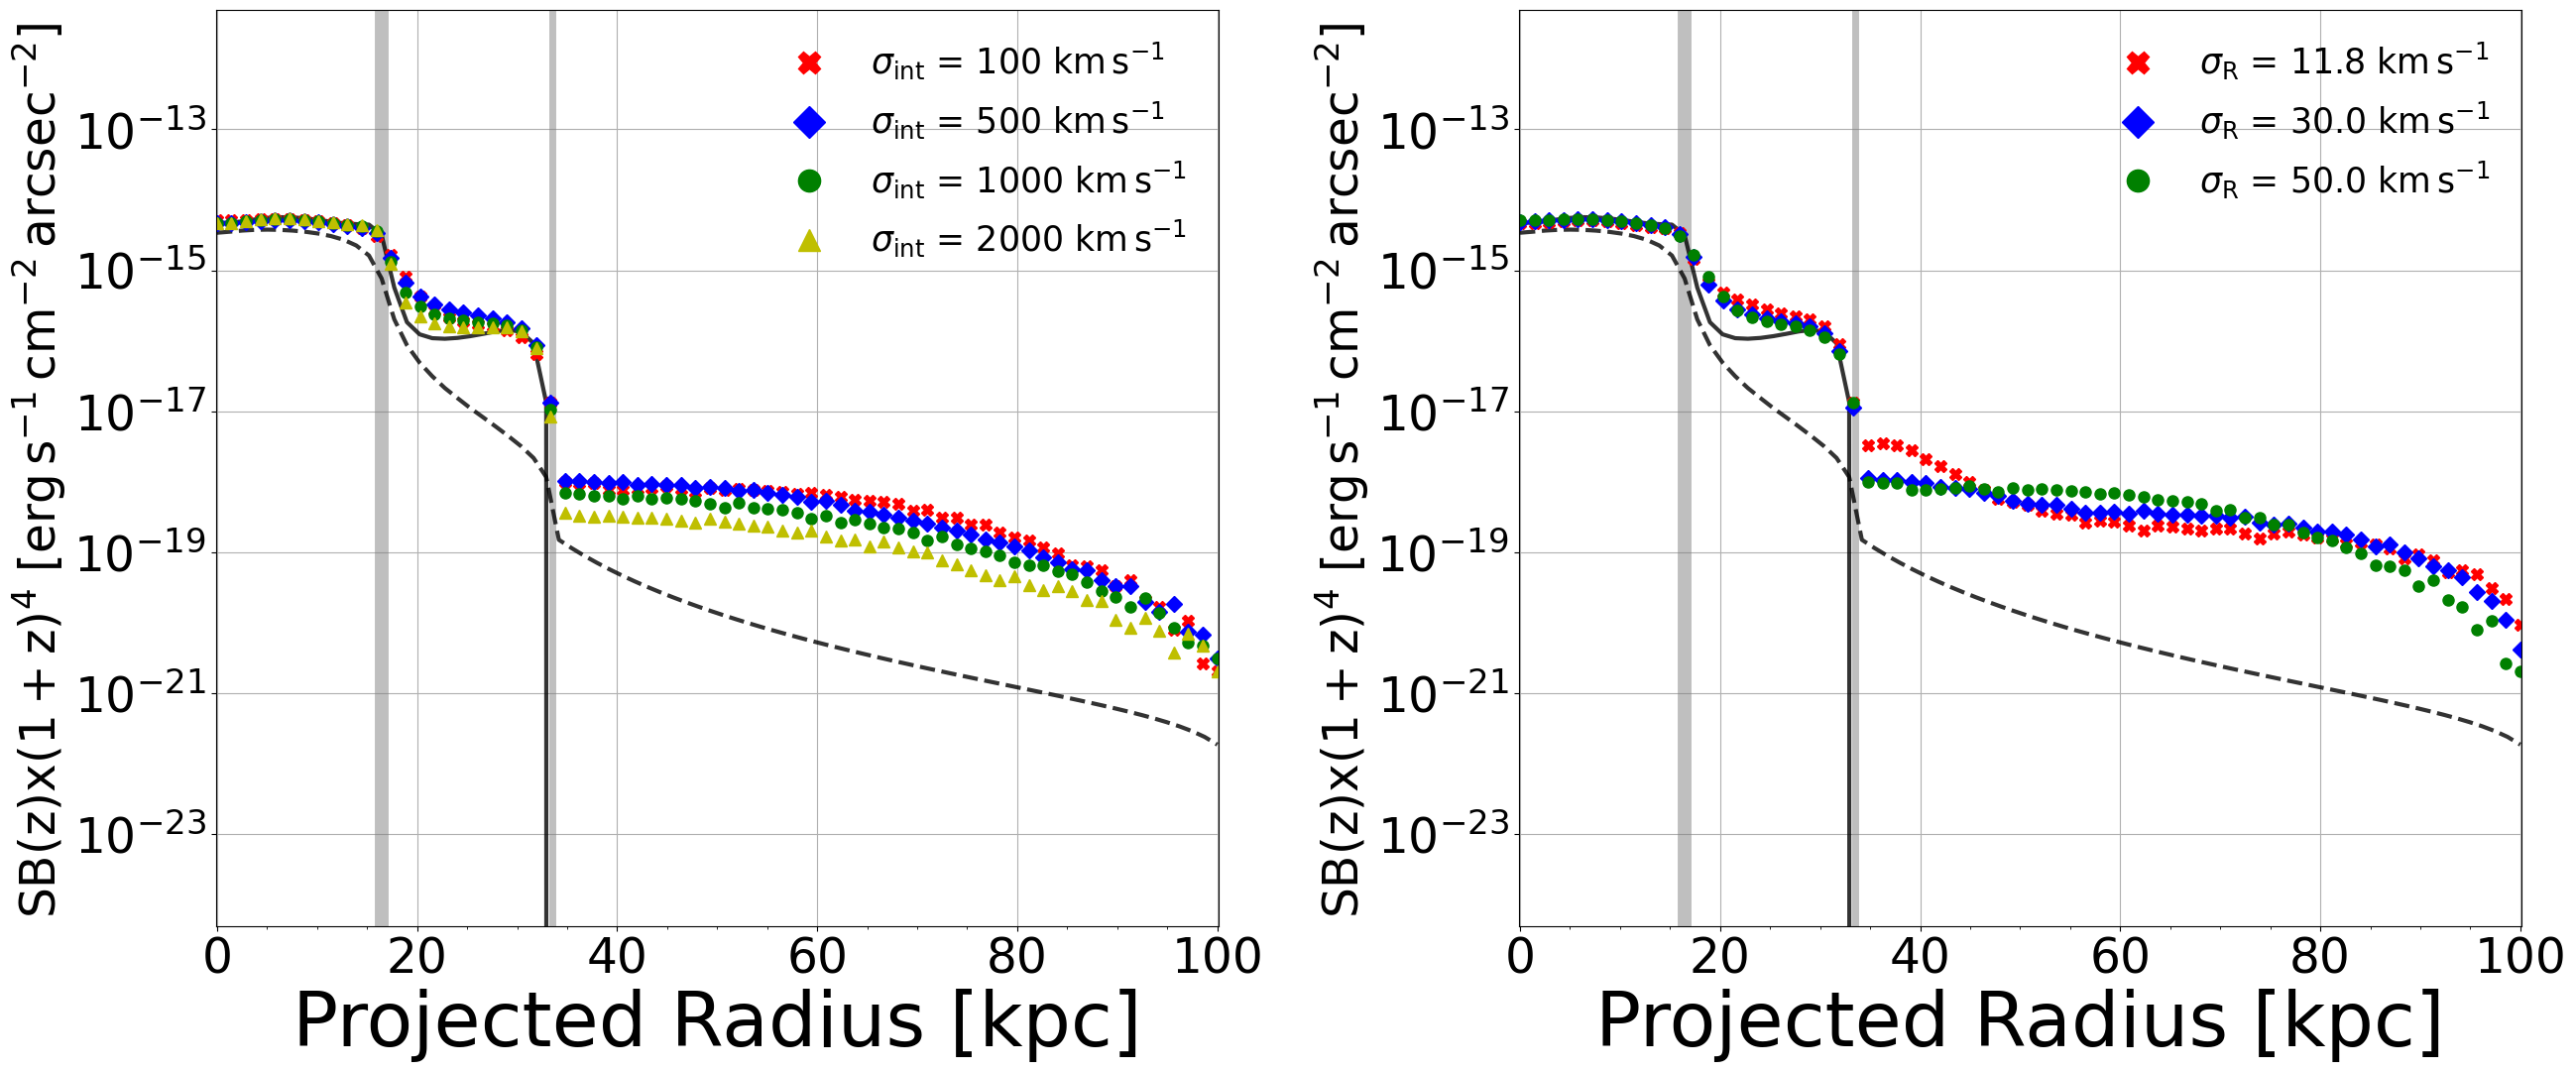

In [44]:

import matplotlib.gridspec as gridspec

import matplotlib.lines as mlines

fig = plt.figure(figsize=(30, 12))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1],wspace=0.3)  #  , width_ratios=[1, 1],  wspace=0.55 

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])


Lum = 44

version = 1
N_H = 22.0
multi = 1
tur = 50.0


# === 첫 번째 subplot ===
z = 0
red_shift_f = (1+z)**4
sr_to_arc = (180*3600 / np.pi)**2
fac = red_shift_f / sr_to_arc

# CLOUDY 데이터 플롯 (레이블 숨김)
ax1.axvline(x=33.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.5,lw=5)
ax1.axvline(x=16.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.5,lw=10)


# CLOUDY 데이터 플롯 (레이블 숨김)
version = 2
CLOUDY_data(Lum, N_H, version, multi)
heii_line = ax1.plot(
    globals()[f'radius_p_{Lum}_{version}'], 
    globals()[f'SB_HeII_{Lum}_{version}'] * fac, 
    '--',color='k',alpha=0.8,lw=3, label='_nolegend_'
)[0]

version = 2
CLOUDY_data(Lum, N_H, version, multi)
civ_line = ax1.plot(
    globals()[f'radius_p_{Lum}_{version}'], 
    globals()[f'SB_CIV_{Lum}_{version}'] * fac, 
    'k-',alpha=0.8,lw=3, label='_nolegend_'
)[0]


v_out = np.array([500]) 
# v_out = 100
v_emit = np.array([100,500,1000,2000]) 
v_rand = np.array([50]) 
# v_rand = np.array([11.8])
z_red_shift = 0


color = ['r','b','g','y']
shape= np.array(['X','D','o','^'])
rt_scat_markers = []
for ii, rr in enumerate(v_emit):
    nn = int(v_out[0]/ 100)
    vout_make_parameter(z_red_shift,Lum,v_out, rr ,v_rand[0])
    a, b = photon_number_SB(
        globals()[f'RT_radius_vout_{nn}'],
        globals()[f'Origin_SB_vout_{nn}'],
        globals()[f'Lumin_CIV_{Lum}_{version}']
    )
    rt_line = ax1.plot(
        globals()[f'RT_radius_vout_{nn}'], 
        b * fac, 
        color=color[ii], 
        linestyle='None',marker=shape[ii],
                     markersize=8,label=f'$\sigma_{{\\rm int}}$ = {rr} ${{\\rm km \\,s ^{{-1}}}}$'
    )[0]
    rt_scat_markers.append(rt_line)


# ax1.legend(handles=legend_elements, loc='best', frameon=False,fontsize=15)
ax1.legend(loc='best', frameon=False,fontsize=25,markerscale=2)



y_min = (b * fac).min() / 5
ax1.set_xlabel('Projected Radius [kpc]', fontsize=55)
ax1.set_xlim(-0.1,100.1)
ax1.set_ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2} \, arcsec^{-2} ]$ ', fontsize=35)
ax1.set_ylim(5e-25,5e-12)
# ax1.text(2.5,y_min, f'$v_{{\\rm out}} = {v_out[0]}~{{\\rm km \\,s ^{{-1}}}}$',fontsize=18,fontweight='bold')


ax1.set_yscale('log')
ax1.tick_params(axis='both', labelsize=35)
ax1.minorticks_on()
ax1.grid(True)
# ax1.text(3,1e-13,s=r'$\nu L_{\nu} = 10^{44}~{\rm erg \, s^{-1}}$',fontsize=35,weight='bold')


Lum = 44

version = 1
N_H = 22.0
multi = 1
tur = 50.0


# === 첫 번째 subplot ===
z = 0
red_shift_f = (1+z)**4
sr_to_arc = (180*3600 / np.pi)**2
fac = red_shift_f / sr_to_arc

# CLOUDY 데이터 플롯 (레이블 숨김)
ax2.axvline(x=33.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.5,lw=5)
ax2.axvline(x=16.5,ymin=0,ymax=1,linestyle='-',color='gray',alpha=0.5,lw=10)


# CLOUDY 데이터 플롯 (레이블 숨김)
version = 2
CLOUDY_data(Lum, N_H, version, multi)
heii_line = ax2.plot(
    globals()[f'radius_p_{Lum}_{version}'], 
    globals()[f'SB_HeII_{Lum}_{version}'] * fac, 
    '--',color='k',alpha=0.8,lw=3, label='_nolegend_'
)[0]

version = 2
CLOUDY_data(Lum, N_H, version, multi)
civ_line = ax2.plot(
    globals()[f'radius_p_{Lum}_{version}'], 
    globals()[f'SB_CIV_{Lum}_{version}'] * fac, 
    'k-',alpha=0.8,lw=3, label='_nolegend_'
)[0]


v_out = np.array([500]) 
# v_out = 100
v_emit = np.array([100]) 
v_rand = np.array([11.8,30,50]) 
# v_rand = np.array([11.8])
z_red_shift = 0


color = ['r','b','g','y']
shape= np.array(['X','D','o','^'])
rt_scat_markers = []
for ii, rr in enumerate(v_rand):
    nn = int(v_out[0]/ 100)
    vout_make_parameter(z_red_shift,Lum,v_out, v_emit[0] ,rr)
    a, b = photon_number_SB(
        globals()[f'RT_radius_vout_{nn}'],
        globals()[f'Origin_SB_vout_{nn}'],
        globals()[f'Lumin_CIV_{Lum}_{version}']
    )
    rt_line = ax2.plot(
        globals()[f'RT_radius_vout_{nn}'], 
        b * fac, 
        color=color[ii], 
        linestyle='None',marker=shape[ii],
                     markersize=8,label=f'$\sigma_{{\\rm R}}$ = {rr} ${{\\rm km \\,s ^{{-1}}}}$'
    )[0]
    rt_scat_markers.append(rt_line)


# ax2.legend(handles=legend_elements, loc='best', frameon=False,fontsize=15)
ax2.legend(loc='best', frameon=False,fontsize=25,markerscale=2)



y_min = (b * fac).min() / 5
ax2.set_xlabel('Projected Radius [kpc]', fontsize=55)
ax2.set_xlim(-0.1,100.1)
ax2.set_ylabel(r'$\rm SB(z) x (1+z)^4$ $\rm [erg \,s^{-1} \, cm^{-2} \, arcsec^{-2} ]$ ', fontsize=35)
ax2.set_ylim(5e-25,5e-12)
# ax2.text(2.5,y_min, f'$v_{{\\rm out}} = {v_out[0]}~{{\\rm km \\,s ^{{-1}}}}$',fontsize=18,fontweight='bold')


ax2.set_yscale('log')
ax2.tick_params(axis='both', labelsize=35)
ax2.minorticks_on()
ax2.grid(True)
# ax2.text(3,1e-13,s=r'$\nu L_{\nu} = 10^{44}~{\rm erg \, s^{-1}}$',fontsize=35,weight='bold')

# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/RT_Scat_result_Random_intrinsic.pdf',bbox_inches="tight")

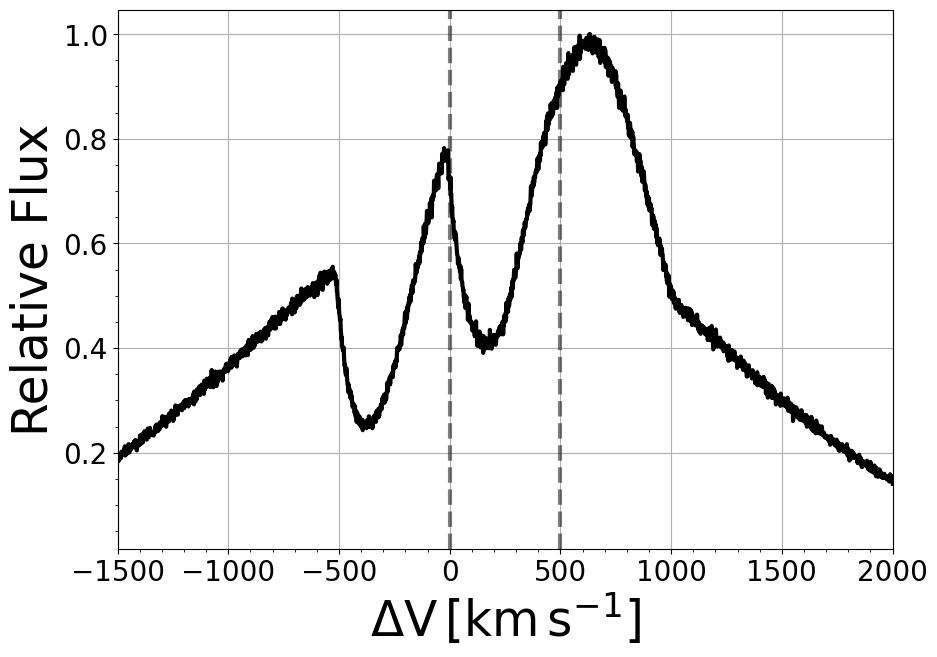

In [45]:
import math
fig = plt.figure(1,figsize=(10,7))

# plt.subplot(121)

vout,vemit,vran = 500, 1000,11.8
Lum = 45.5
normal = K_H_from_Combine_data_RT('all',Lum, vout,vemit,vran)[1].max()
plt.plot(lam_to_vel(K_H_from_Combine_data_RT('all',Lum, vout,vemit,vran)[0]),K_H_from_Combine_data_RT('all',Lum, vout,vemit,vran)[1]/normal,'k-',lw=3,alpha=1,label=f'{vout}')

# vout = 500
# plt.plot(lam_to_vel(K_H_from_Combine_data_RT('all',Lum, vout,vemit,vran)[0]),K_H_from_Combine_data_RT('all',Lum, vout,vemit,vran)[1]/normal,'k-',lw=4,alpha=0.9,label=f'{vout}')


# plt.axvline(x=250,ymin=0,ymax=5,color='r',linestyle='--',lw = 2)
plt.axvline(x=0,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)
plt.axvline(x=500,ymin=0,ymax=5,color='k',linestyle='--',lw = 3,alpha=0.5)

plt.xlim(-1500, 2000)

plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

plt.xlabel(r'$\Delta \rm V \, [\rm km\,s^{-1}]$',fontsize=35)
plt.ylabel(r'Relative Flux',fontsize=35)


# plt.legend(title = r'$V_{\rm out}~[\rm km\,s^{-1}]$',title_fontsize=35,fontsize=30,frameon=False)
plt.minorticks_on()
plt.grid(True)


# plt.savefig(f'/mnt/c/Users/wlsdl/OneDrive/바탕 화면/RT_Scat_result_example_AGN.pdf',bbox_inches="tight") 
